PdCO ephys pilot experiment - JL 4/2026

In [1]:
import os, sys

notebook_dir = "/code/beh_ephys_analysis"
if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)

In [2]:
from behavior_and_time_alignment import beh_and_time_alignment
from session_preprocessing import ephys_opto_preprocessing, session_crosscorr, ephys_opto_crosscorr
from opto_tagging import opto_plotting_session, opto_plotting_unit
from opto_waveforms_preprocessing import opto_wf_preprocessing
from drift_analysis import plot_session_opto_drift
import matplotlib.pyplot as plt
from utils.beh_functions import session_dirs, get_unit_tbl
import numpy as np
import pandas as pd
import os
from utils.plot_utils import combine_pdf_big
import spikeinterface as si
from joblib import Parallel, delayed
import pickle

In [33]:
from pathlib import Path
import spikeinterface.extractors as se

zarr_path = Path(
   #"/root/capsule/data/behavior_826748_2026-03-31_08-30-45_raw_data/ecephys/ecephys_compressed/experiment1_Record Node 101#NI-DAQmx-107.PXIe-6341.zarr"
   #"/root/capsule/data/behavior_826748_2026-04-01_08-57-33_raw_data/ecephys/ecephys_compressed/experiment1_Record Node 101#NI-DAQmx-107.PXIe-6341.zarr"
   #"/root/capsule/data/behavior_826748_2026-04-02_09-21-15_raw_data/ecephys/ecephys_compressed/experiment1_Record Node 101#NI-DAQmx-107.PXIe-6341.zarr"
   "/root/capsule/data/behavior_826748_2026-04-03_08-53-15_raw_data/ecephys/ecephys_compressed/experiment1_Record Node 101#NI-DAQmx-107.PXIe-6341.zarr"
)

rec_ni = se.read_zarr(zarr_path)

print(rec_ni)
print("channel ids:", rec_ni.get_channel_ids())
print("fs:", rec_ni.get_sampling_frequency())
print("num segments:", rec_ni.get_num_segments())

for seg in range(rec_ni.get_num_segments()):
    n = rec_ni.get_num_frames(segment_index=seg)
    print(f"segment {seg}: {n} samples, {n / rec_ni.get_sampling_frequency():.3f} s")

ZarrRecordingExtractor: 8 channels - 30.0kHz - 2 segments - 97,532,980 samples 
                        3,250.76s (54.18 minutes) - int16 dtype - 1.45 GiB
Segments:
Samples:   92,335,480 | 5,197,500
Durations: 3,077.53s (51.29 minutes) | 173.23s (2.89 minutes)
Memory:    1.38 GiB | 79.31 MiB
channel ids: ['AI0' 'AI1' 'AI2' 'AI3' 'AI4' 'AI5' 'AI6' 'AI7']
fs: 30000.0
num segments: 2
segment 0: 92335480 samples, 3077.849 s
segment 1: 5197500 samples, 173.250 s


In [10]:
from pathlib import Path
import numpy as np
import zarr

zarr_path = Path(
    "/root/capsule/data/behavior_826748_2026-03-31_08-30-45_raw_data/ecephys/ecephys_compressed/experiment1_Record Node 101#NI-DAQmx-107.PXIe-6341.zarr"
)

npy_path = Path(
    "/root/capsule/data/behavior_826748_2026-03-31_08-30-45_raw_data/ecephys/ecephys_clipped/Record Node 101/experiment1/recording1/continuous/NI-DAQmx-107.PXIe-6341/timestamps.npy"
)

# Open zarr and inspect keys
root = zarr.open(str(zarr_path), mode="r")
print("Zarr keys:", list(root.keys()))

# Usually segment 0 corresponds to recording1
zarr_times = np.asarray(root["times_seg0"])
npy_times = np.load(npy_path)

print("zarr_times shape:", zarr_times.shape)
print("npy_times shape:", npy_times.shape)

# Exact equality
same_shape = zarr_times.shape == npy_times.shape
print("same shape:", same_shape)

if same_shape:
    print("exactly equal:", np.array_equal(zarr_times, npy_times))
    print("allclose:", np.allclose(zarr_times, npy_times, rtol=0, atol=1e-12))
    print("max abs diff:", np.max(np.abs(zarr_times - npy_times)))
else:
    n = min(len(zarr_times), len(npy_times))
    print("prefix exactly equal:", np.array_equal(zarr_times[:n], npy_times[:n]))
    print("prefix allclose:", np.allclose(zarr_times[:n], npy_times[:n], rtol=0, atol=1e-12))
    print("prefix max abs diff:", np.max(np.abs(zarr_times[:n] - npy_times[:n])))

print("first 5 zarr:", zarr_times[:5])
print("first 5 npy :", npy_times[:5])
print("last 5 zarr :", zarr_times[-5:])
print("last 5 npy  :", npy_times[-5:])

Zarr keys: ['channel_ids', 'properties', 'times_seg0', 'times_seg1', 'traces_seg0', 'traces_seg1']
zarr_times shape: (99067500,)
npy_times shape: (99067500,)
same shape: True
exactly equal: True
allclose: True
max abs diff: 0.0
first 5 zarr: [17530966.53308615 17530966.53311948 17530966.53315281 17530966.53318614
 17530966.53321947]
first 5 npy : [17530966.53308615 17530966.53311948 17530966.53315281 17530966.53318614
 17530966.53321947]
last 5 zarr : [17534268.43997099 17534268.44000432 17534268.44003765 17534268.44007098
 17534268.44010431]
last 5 npy  : [17534268.43997099 17534268.44000432 17534268.44003765 17534268.44007098
 17534268.44010431]


In [34]:
import numpy as np
import pandas as pd

# MORE EFFICIENT Two-pass transition detector:
# Pass 1: coarse scan in bins to find candidate transition windows
# Pass 2: read only around those candidate windows at full resolution to find exact sample crossings

segment_index = 0
channels = ["AI0", "AI2"]
threshold = 2000

# ---------- Pass 1 settings ----------
coarse_bin_s = 0.5          # coarse bins for fast scan; use 0.1 if pulses are very brief
coarse_chunk_s = 120        # read in large chunks
coarse_bin_size = int(rec_ni.get_sampling_frequency() * coarse_bin_s)
coarse_chunk_frames = int(rec_ni.get_sampling_frequency() * coarse_chunk_s)

fs = rec_ni.get_sampling_frequency()
n_frames = rec_ni.get_num_frames(segment_index=segment_index)

# Use the aligned timestamp base without loading the entire time vector
times0 = rec_ni.get_times(segment_index=segment_index)[:2]
t0 = float(times0[0])
dt = float(times0[1] - times0[0])

# ---------- Pass 1: coarse binary scan ----------
coarse_state = {ch: [] for ch in channels}
coarse_bin_start_frames = []

for chunk_start in range(0, n_frames, coarse_chunk_frames):
    chunk_end = min(chunk_start + coarse_chunk_frames, n_frames)

    raw = rec_ni.get_traces(
        segment_index=segment_index,
        start_frame=chunk_start,
        end_frame=chunk_end,
        channel_ids=channels,
    )  # shape: (samples, n_channels)

    usable = (raw.shape[0] // coarse_bin_size) * coarse_bin_size
    if usable == 0:
        continue

    # reshape to (n_bins, bin_size, n_channels)
    raw_b = raw[:usable].reshape(-1, coarse_bin_size, len(channels))

    # use max within bin so brief high pulses are not averaged away
    coarse_vals = raw_b.max(axis=1)  # shape: (n_bins, n_channels)
    coarse_binary = (coarse_vals > threshold).astype(np.uint8)

    n_bins = coarse_binary.shape[0]
    bin_frames = chunk_start + np.arange(n_bins) * coarse_bin_size
    coarse_bin_start_frames.append(bin_frames)

    for j, ch in enumerate(channels):
        coarse_state[ch].append(coarse_binary[:, j])

coarse_bin_start_frames = np.concatenate(coarse_bin_start_frames)
for ch in channels:
    coarse_state[ch] = np.concatenate(coarse_state[ch])

# ---------- Identify candidate transition windows ----------
candidate_windows = {ch: [] for ch in channels}

for ch in channels:
    y = coarse_state[ch]
    trans_bins = np.where(np.diff(y.astype(np.int8)) != 0)[0] + 1

    for b in trans_bins:
        # search around the coarse transition bin boundary
        start_frame = max(0, coarse_bin_start_frames[b] - coarse_bin_size)
        end_frame = min(n_frames, coarse_bin_start_frames[b] + coarse_bin_size)
        direction = "up" if (y[b - 1] == 0 and y[b] == 1) else "down"
        candidate_windows[ch].append((start_frame, end_frame, direction))

# ---------- Pass 2: refine exact crossings ----------
rows = []

for ch in channels:
    for start_frame, end_frame, direction in candidate_windows[ch]:
        raw = rec_ni.get_traces(
            segment_index=segment_index,
            start_frame=start_frame,
            end_frame=end_frame,
            channel_ids=[ch],
        ).squeeze()

        above = raw > threshold
        diff = np.diff(above.astype(np.int8))

        if direction == "up":
            rel_idx = np.where(diff == 1)[0] + 1
        else:
            rel_idx = np.where(diff == -1)[0] + 1

        if len(rel_idx) == 0:
            continue

        # pick the first crossing in the candidate window
        i = int(start_frame + rel_idx[0])

        rows.append({
            "channel": ch,
            "transition": direction,
            "sample_index": i,
            "timestamp_sec": t0 + i * dt,
            "value": int(raw[rel_idx[0]]),
        })

transition_df = (
    pd.DataFrame(rows)
    .drop_duplicates(subset=["channel", "transition", "sample_index"])
    .sort_values(["timestamp_sec", "channel"])
    .reset_index(drop=True)
)

transition_df

,channel,transition,sample_index,timestamp_sec,value
0,AI0,up,13964561,1.779198e+07,16228
1,AI0,down,14414625,1.779200e+07,1661
2,AI2,up,33181302,1.779262e+07,15961
3,AI2,down,33631367,1.779264e+07,-127
4,AI0,up,44284795,1.779299e+07,16254
5,AI0,down,44734860,1.779301e+07,82
6,AI2,up,55690655,1.779337e+07,15952
7,AI2,down,56140720,1.779339e+07,-7
8,AI0,up,66500744,1.779373e+07,16225
9,AI0,down,66950809,1.779375e+07,27


In [35]:
import os
session = 'behavior_826748_2026-04-03_08-53-15'
sd = session_dirs(session)
save_path = os.path.join(sd["opto_dir"], "transition_df.csv")

os.makedirs(sd["opto_dir"], exist_ok=True)
transition_df.to_csv(save_path, index=False)

print(f"Saved transition_df to: {save_path}")

Saved transition_df to: /root/capsule/scratch/826748/behavior_826748_2026-04-03_08-53-15/ephys/opto/transition_df.csv


In [31]:
import pandas as pd

# Either use the existing save_path variable, or set an explicit path:
# csv_path = save_path
csv_path = "/root/capsule/scratch/826748/behavior_826748_2026-03-31_08-30-45/ephys/opto/transition_df.csv"

transition_df = pd.read_csv(csv_path)

print(f"Loaded transition_df from: {csv_path}")
print(f"Shape: {transition_df.shape}")
display(transition_df.head())

Loaded transition_df from: /root/capsule/scratch/826748/behavior_826748_2026-03-31_08-30-45/ephys/opto/transition_df.csv
Shape: (12, 5)


,channel,transition,sample_index,timestamp_sec,value
0,AI0,up,12779595,1.753139e+07,16300
1,AI0,down,13229660,1.753141e+07,72
2,AI2,up,30549530,1.753198e+07,16060
3,AI2,down,30999595,1.753200e+07,-19
4,AI0,up,43407462,1.753241e+07,16217


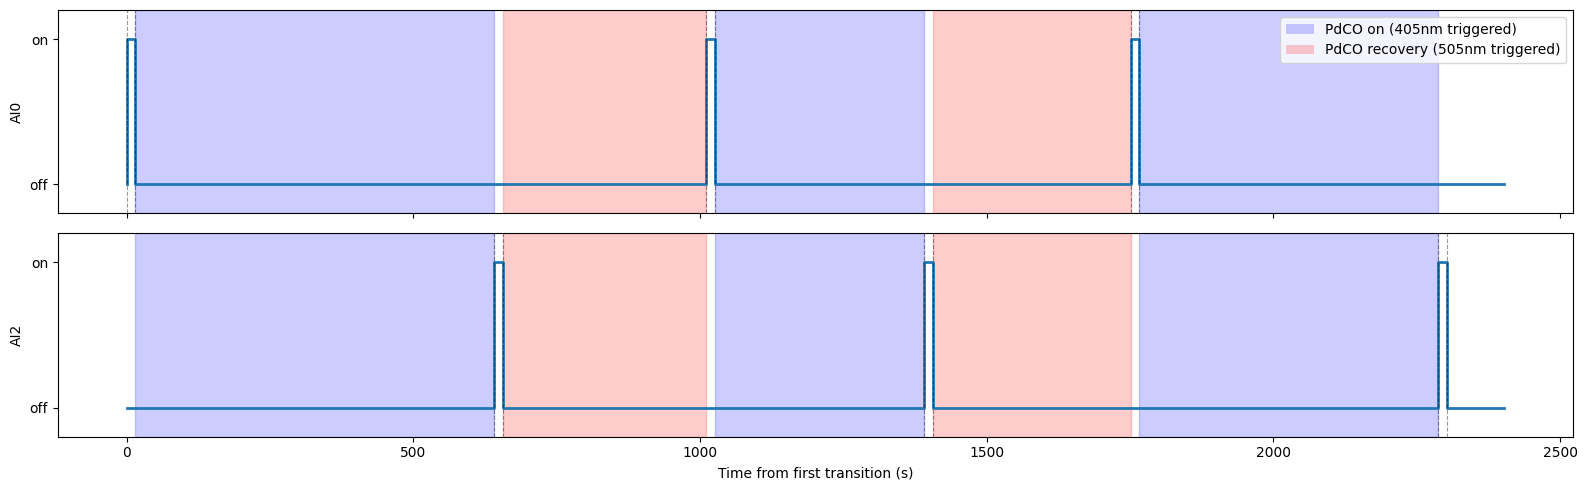

Time zero = 17791981.641234 (original timestamp_sec)
Blue intervals (AI0-off -> AI2-on), plotted time:
  15.001 s -> 640.497 s
  1025.579 s -> 1390.738 s
  1766.041 s -> 2287.006 s

Red intervals (AI2-off -> AI0-on), plotted time:
  655.498 s -> 1010.579 s
  1405.739 s -> 1751.040 s


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Assumes transition_df has columns:
#   channel, transition, timestamp_sec
# where channel is 'AI0' or 'AI2' and transition is 'up'/'down'

# ----------------------------
# Extract transition times
# ----------------------------
ai0_df = transition_df.query("channel == 'AI0'").sort_values("timestamp_sec").copy()
ai2_df = transition_df.query("channel == 'AI2'").sort_values("timestamp_sec").copy()

# Convert to absolute time starting at 0 s
t0 = transition_df["timestamp_sec"].min()
ai0_df["t_plot"] = ai0_df["timestamp_sec"] - t0
ai2_df["t_plot"] = ai2_df["timestamp_sec"] - t0

ai0_transitions = ai0_df["t_plot"].to_numpy()
ai2_transitions = ai2_df["t_plot"].to_numpy()

ai0_on = ai0_df.query("transition == 'up'")["t_plot"].to_numpy()
ai0_off = ai0_df.query("transition == 'down'")["t_plot"].to_numpy()

ai2_on = ai2_df.query("transition == 'up'")["t_plot"].to_numpy()
ai2_off = ai2_df.query("transition == 'down'")["t_plot"].to_numpy()

# ----------------------------
# Helper: build binary state from transitions
# ----------------------------
def build_step_xy_from_df(trans_df, t_start=None, t_end=None, start_state=0):
    trans_df = trans_df.sort_values("t_plot")
    times = trans_df["t_plot"].to_numpy()
    transitions = trans_df["transition"].to_numpy()

    if t_start is None:
        t_start = 0.0
    if t_end is None:
        t_end = times.max() + 100 if len(times) else 100.0

    x = [t_start]
    y = [start_state]
    state = start_state

    for t, tr in zip(times, transitions):
        x.append(t)
        y.append(state)
        state = 1 if tr == "up" else 0
        x.append(t)
        y.append(state)

    x.append(t_end)
    y.append(state)

    return np.array(x), np.array(y)

# Plot range
all_times = np.concatenate([ai0_transitions, ai2_transitions]) if (len(ai0_transitions) + len(ai2_transitions)) > 0 else np.array([0.0, 100.0])
t_start_plot = 0.0
t_end_plot = all_times.max() + 100

x0, y0 = build_step_xy_from_df(ai0_df, t_start=t_start_plot, t_end=t_end_plot, start_state=0)
x2, y2 = build_step_xy_from_df(ai2_df, t_start=t_start_plot, t_end=t_end_plot, start_state=0)

# ----------------------------
# Shaded intervals
# Blue: AI0-off -> next AI2-on
# Red:  AI2-off -> next AI0-on
# ----------------------------
blue_intervals = []
for t_off in ai0_off:
    idx = np.searchsorted(ai2_on, t_off, side="right")
    if idx < len(ai2_on):
        t_on = ai2_on[idx]
        if t_on > t_off:
            blue_intervals.append((t_off, t_on))

red_intervals = []
for t_off in ai2_off:
    idx = np.searchsorted(ai0_on, t_off, side="right")
    if idx < len(ai0_on):
        t_on = ai0_on[idx]
        if t_on > t_off:
            red_intervals.append((t_off, t_on))

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(2, 1, figsize=(16, 5), sharex=True)

for ax in axes:
    for a, b in blue_intervals:
        ax.axvspan(a, b, alpha=0.20, color="blue")
    for a, b in red_intervals:
        ax.axvspan(a, b, alpha=0.20, color="red")

axes[0].step(x0, y0, where="post", lw=2)
axes[0].set_ylabel("AI0")
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(["off", "on"])
axes[0].set_ylim(-0.2, 1.2)

axes[1].step(x2, y2, where="post", lw=2)
axes[1].set_ylabel("AI2")
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["off", "on"])
axes[1].set_ylim(-0.2, 1.2)
axes[1].set_xlabel("Time from first transition (s)")

# Optional transition markers
for t in ai0_transitions:
    axes[0].axvline(t, color="k", ls="--", lw=0.8, alpha=0.4)
for t in ai2_transitions:
    axes[1].axvline(t, color="k", ls="--", lw=0.8, alpha=0.4)

legend_handles = [
    Patch(facecolor="blue", alpha=0.20, label="PdCO on (405nm triggered)"),
    Patch(facecolor="red",  alpha=0.20, label="PdCO recovery (505nm triggered)"),
]
axes[0].legend(handles=legend_handles, loc="upper right")

plt.tight_layout()
plt.show()

print(f"Time zero = {t0:.6f} (original timestamp_sec)")
print("Blue intervals (AI0-off -> AI2-on), plotted time:")
for a, b in blue_intervals:
    print(f"  {a:.3f} s -> {b:.3f} s")

print("\nRed intervals (AI2-off -> AI0-on), plotted time:")
for a, b in red_intervals:
    print(f"  {a:.3f} s -> {b:.3f} s")

In [37]:
import os
import numpy as np
import spikeinterface.full as si

sd = session_dirs(session)

sorting_path = os.path.join(
    sd["sorted_dir_raw"],
    "spikesorted",
    sd["stream_name"],
)

recording_path = sd["raw_rec"]
segment_index = sd["seg_id"] - 1

print("sorting_path:", sorting_path)
print("exists:", os.path.exists(sorting_path))
print("recording_path:", recording_path)

sorting = si.load(sorting_path)
recording = si.load(recording_path)

unit_ids = sorting.get_unit_ids()
times = recording.get_times(segment_index=segment_index)

spiketimes = {}
for unit_id in unit_ids:
    spike_samples = sorting.get_unit_spike_train(
        unit_id=unit_id,
        segment_index=segment_index
    )
    spiketimes[unit_id] = times[spike_samples]

print(f"Built spike times for {len(spiketimes)} units")
uid = unit_ids[0]
print("Example unit:", uid)
print(spiketimes[uid][:10])

sorting_path: /root/capsule/data/behavior_826748_2026-04-03_08-53-15_sorted/spikesorted/experiment1_Record Node 101#Neuropix-PXI-100.ProbeA_recording1
exists: True
recording_path: /root/capsule/data/behavior_826748_2026-04-03_08-53-15_raw_data/ecephys/ecephys_compressed/experiment1_Record Node 101#Neuropix-PXI-100.ProbeA.zarr
Built spike times for 238 units
Example unit: 0
[17791622.46605552 17791629.79834135 17791728.61417278 17791765.23444894
 17791802.04244424 17791802.18894592 17791810.20316614 17791832.16300128
 17791836.39143284 17791854.06647864]


Unit 23
Number of alignment events: 4
  channel transition  timestamp_sec  map_value
0     AI0         up   1.770724e+07          0
1     AI2         up   1.770790e+07          1
2     AI0         up   1.770849e+07          0
3     AI2         up   1.770929e+07          1


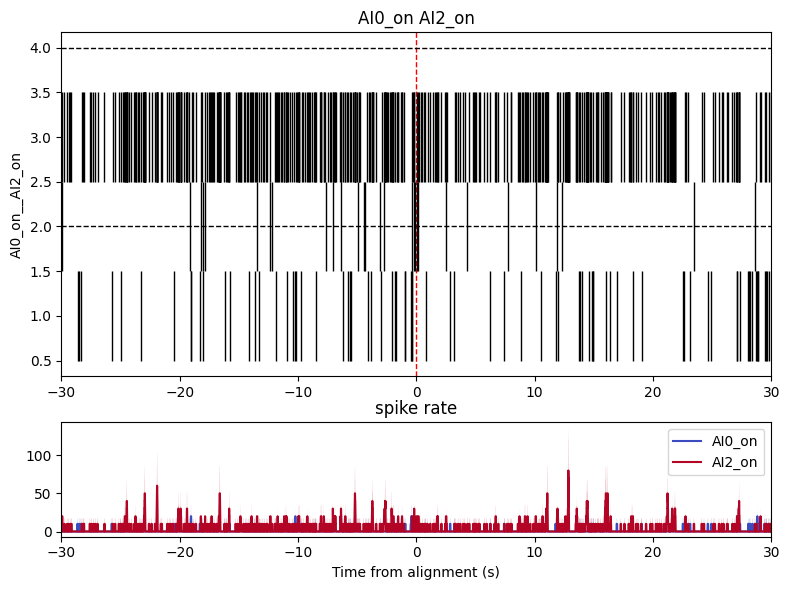

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from utils.ephys_functions import plot_raster_rate

# ----------------------------
# Choose unit and event type
# ----------------------------
unit_id = 23
transition_type = "up"   # "up" = onset, "down" = offset

# spike times for this unit
spike_times = np.asarray(spiketimes[unit_id])

# ----------------------------
# Build align_events + map_value
# ----------------------------
# Keep only the chosen transition type for AI0 and AI2
event_df = transition_df.query(
    "transition == @transition_type and channel in ['AI0', 'AI2']"
).copy()

# map_value:
#   0 -> AI0
#   1 -> AI2
event_df["map_value"] = (event_df["channel"] == "AI2").astype(int)

# sort by timestamp for cleanliness
event_df = event_df.sort_values("timestamp_sec").reset_index(drop=True)

align_events = event_df["timestamp_sec"].to_numpy()
map_value = event_df["map_value"].to_numpy()

# bins and labels for the two conditions
bins = [-0.5, 0.5, 1.5]
labels = ["AI0_on", "AI2_on"] if transition_type == "up" else ["AI0_off", "AI2_off"]

# choose any matplotlib colormap you like
colormap = plt.cm.coolwarm

print(f"Unit {unit_id}")
print(f"Number of alignment events: {len(align_events)}")
print(event_df[["channel", "transition", "timestamp_sec", "map_value"]])

# ----------------------------
# Plot
# ----------------------------
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(1, 1, figure=fig)

fig, ax1, ax2 = plot_raster_rate(
    spike_times=spike_times,
    align_events=align_events,
    map_value=map_value,
    bins=bins,
    labels=labels,
    colormap=colormap,
    fig=fig,
    subplot_spec=gs[0],
    tb=-30,
    tf=30,
    time_bin=0.05,
    step_size=0.01,
    kernel=False,
    avoid_overlap=True,
)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from utils.ephys_functions import plot_raster_rate

# ----------------------------
# User inputs
# ----------------------------
unit_ids_to_plot = [1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 100]
transition_type = "up"          # "up" = onset, "down" = offset

# Time window / binning for plot_raster_rate
tb = -30
tf = 30
time_bin = 0.05
step_size = 0.01

# ----------------------------
# Build align_events + map_value once
# ----------------------------
event_df = transition_df.query(
    "transition == @transition_type and channel in ['AI0', 'AI2']"
).copy()

# 0 = AI0, 1 = AI2
event_df["map_value"] = (event_df["channel"] == "AI2").astype(int)
event_df = event_df.sort_values("timestamp_sec").reset_index(drop=True)

align_events = event_df["timestamp_sec"].to_numpy()
map_value = event_df["map_value"].to_numpy()

bins = [-0.5, 0.5, 1.5]
labels = ["AI0_on", "AI2_on"] if transition_type == "up" else ["AI0_off", "AI2_off"]
colormap = plt.cm.coolwarm

print(f"Number of alignment events: {len(align_events)}")
print(event_df[["channel", "transition", "timestamp_sec", "map_value"]])

# ----------------------------
# Loop over units
# ----------------------------
for unit_id in unit_ids_to_plot:
    if unit_id not in spiketimes:
        print(f"Skipping unit {unit_id}: not found in spiketimes")
        continue

    spike_times = np.asarray(spiketimes[unit_id])

    fig = plt.figure(figsize=(8, 6))
    gs = gridspec.GridSpec(1, 1, figure=fig)

    fig, ax1, ax2 = plot_raster_rate(
        spike_times=spike_times,
        align_events=align_events,
        map_value=map_value,
        bins=bins,
        labels=labels,
        colormap=colormap,
        fig=fig,
        subplot_spec=gs[0],
        tb=tb,
        tf=tf,
        time_bin=time_bin,
        step_size=step_size,
        kernel=False,
        avoid_overlap=True,
    )

    ax1.set_title(f"Unit {unit_id} | " + " ".join(labels))
    plt.tight_layout()
    plt.show()

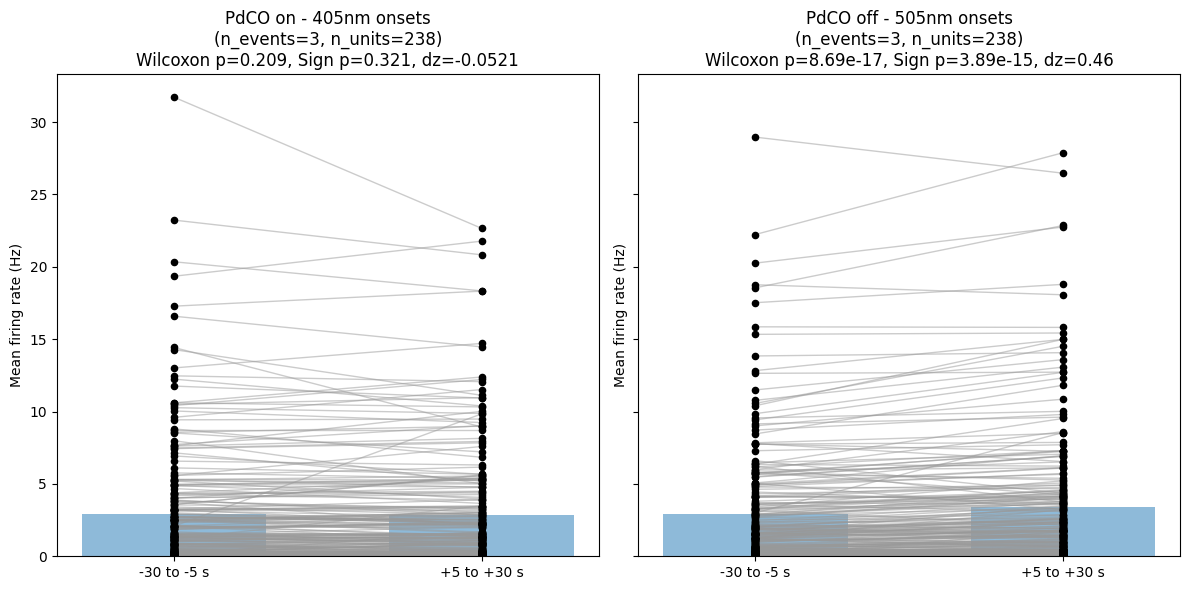

,condition,n_events,n_units,mean_before_rate_hz,mean_after_rate_hz,mean_diff_rate_hz,median_diff_rate_hz,wilcoxon_p,sign_test_p,cohen_dz,n_pos,n_neg,n_zero
0,PdCO on - 405nm onsets,3,238,2.931709,2.873109,-0.058599,-0.013333,2.092383e-01,3.205188e-01,-0.052095,106,122,10
1,PdCO off - 505nm onsets,3,238,2.922185,3.390476,0.468291,0.180000,8.692930e-17,3.890648e-15,0.459748,175,57,6


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, binomtest

# ----------------------------
# Settings
# ----------------------------
window_start = 5
window_end = 30
window_len = window_end - window_start

event_sets = {
    "PdCO on - 405nm onsets": transition_df.query("channel == 'AI0' and transition == 'up'")["timestamp_sec"].to_numpy(),
    "PdCO off - 505nm onsets": transition_df.query("channel == 'AI2' and transition == 'up'")["timestamp_sec"].to_numpy(),
}

# ----------------------------
# Helper
# ----------------------------
def compute_before_after_df_offset(spiketimes, event_times, window_start, window_end):
    event_times = np.sort(np.asarray(event_times))
    window_len = window_end - window_start
    rows = []

    for unit_id, spike_times in spiketimes.items():
        spike_times = np.asarray(spike_times)

        before_rates = []
        after_rates = []

        for t in event_times:
            n_before = np.sum((spike_times >= t - window_end) & (spike_times < t - window_start))
            n_after  = np.sum((spike_times >= t + window_start) & (spike_times < t + window_end))

            before_rates.append(n_before / window_len)
            after_rates.append(n_after / window_len)

        rows.append({
            "unit_id": unit_id,
            "before_mean_rate_hz": np.mean(before_rates) if len(before_rates) else np.nan,
            "after_mean_rate_hz": np.mean(after_rates) if len(after_rates) else np.nan,
            "n_events": len(event_times),
        })

    return pd.DataFrame(rows).sort_values("unit_id").reset_index(drop=True)

results_offset = {
    name: compute_before_after_df_offset(spiketimes, ev, window_start, window_end)
    for name, ev in event_sets.items()
}

# ----------------------------
# Plot + stats
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

stats_rows = []

for ax, (name, df) in zip(axes, results_offset.items()):
    before_vals = df["before_mean_rate_hz"].to_numpy()
    after_vals = df["after_mean_rate_hz"].to_numpy()

    valid = np.isfinite(before_vals) & np.isfinite(after_vals)
    before_vals = before_vals[valid]
    after_vals = after_vals[valid]
    diff = after_vals - before_vals

    mean_before = np.nanmean(before_vals)
    mean_after = np.nanmean(after_vals)

    try:
        w_stat, w_p = wilcoxon(before_vals, after_vals, zero_method="wilcox")
    except ValueError:
        w_stat, w_p = np.nan, np.nan

    n_pos = np.sum(diff > 0)
    n_neg = np.sum(diff < 0)
    n_zero = np.sum(diff == 0)
    n_nonzero = n_pos + n_neg
    sign_p = binomtest(n_pos, n_nonzero, p=0.5).pvalue if n_nonzero > 0 else np.nan

    dz = np.mean(diff) / np.std(diff, ddof=1) if len(diff) > 1 and np.std(diff, ddof=1) > 0 else np.nan

    stats_rows.append({
        "condition": name,
        "n_events": int(df["n_events"].iloc[0]),
        "n_units": len(before_vals),
        "mean_before_rate_hz": mean_before,
        "mean_after_rate_hz": mean_after,
        "mean_diff_rate_hz": np.mean(diff),
        "median_diff_rate_hz": np.median(diff),
        "wilcoxon_p": w_p,
        "sign_test_p": sign_p,
        "cohen_dz": dz,
        "n_pos": int(n_pos),
        "n_neg": int(n_neg),
        "n_zero": int(n_zero),
    })

    x = np.array([0, 1])
    ax.bar(x, [mean_before, mean_after], width=0.6, alpha=0.5)

    for b, a in zip(before_vals, after_vals):
        ax.plot(x, [b, a], color="0.6", alpha=0.5, linewidth=1)
        ax.scatter(x, [b, a], color="k", s=20, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels([f"-{int(window_end)} to -{int(window_start)} s", f"+{int(window_start)} to +{int(window_end)} s"])
    ax.set_title(
        f"{name}\n"
        f"(n_events={int(df['n_events'].iloc[0])}, n_units={len(before_vals)})\n"
        f"Wilcoxon p={w_p:.3g}, Sign p={sign_p:.3g}, dz={dz:.3g}"
    )
    ax.set_ylabel("Mean firing rate (Hz)")

plt.tight_layout()
plt.show()

stats_df_offset = pd.DataFrame(stats_rows)
stats_df_offset

transition_df preview:


,channel,transition,sample_index,timestamp_sec,value
0,AI0,up,12755133,1.761940e+07,16212
1,AI0,down,13205198,1.761941e+07,47
2,AI2,up,24960737,1.761981e+07,15906
3,AI2,down,25410802,1.761982e+07,24
4,AI0,up,35372715,1.762015e+07,16211



transition_df columns: ['channel', 'transition', 'sample_index', 'timestamp_sec', 'value']
n rows: 14

AI0 onset count: 3
AI2 onset count: 4

LFP sampling rate: 30000.0 Hz
Total LFP frames: 85515208
Total channels: 384
Using channels: 384

Event-level bandpower dataframe:


,stim_type,event_idx,onset_sec,pre_start,pre_end,post_start,post_end,theta_pre,theta_post,theta_diff,theta_log_ratio,beta_pre,beta_post,beta_diff,beta_log_ratio,gamma_pre,gamma_post,gamma_diff,gamma_log_ratio
0,AI0,0,425.171100,395.171100,425.171100,427.171100,457.171100,NaN,NaN,NaN,NaN,29.437297,30.304326,0.867029,0.029028,16.721571,16.386635,-0.334935,-0.020233
1,AI0,1,1179.090500,1149.090500,1179.090500,1181.090500,1211.090500,NaN,NaN,NaN,NaN,28.726694,31.864460,3.137766,0.103664,15.097200,16.996269,1.899069,0.118485
2,AI0,2,2307.791500,2277.791500,2307.791500,2309.791500,2339.791500,NaN,NaN,NaN,NaN,32.111205,30.885571,-1.225633,-0.038916,19.263787,18.521638,-0.742148,-0.039287
3,AI2,0,832.024567,802.024567,832.024567,834.024567,864.024567,NaN,NaN,NaN,NaN,29.572266,27.165797,-2.406469,-0.084878,15.519282,14.488684,-1.030598,-0.068715
4,AI2,1,1660.862467,1630.862467,1660.862467,1662.862467,1692.862467,NaN,NaN,NaN,NaN,30.850200,30.005708,-0.844492,-0.027756,17.259048,16.740146,-0.518902,-0.030527


Total valid events: 7


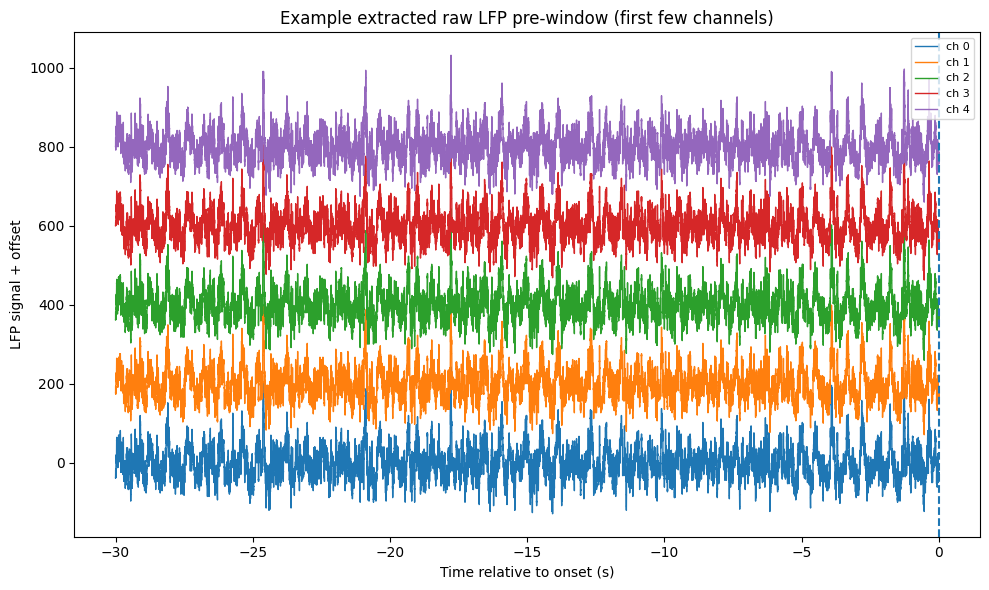

No valid events for AI0, theta
No valid events for AI0, theta


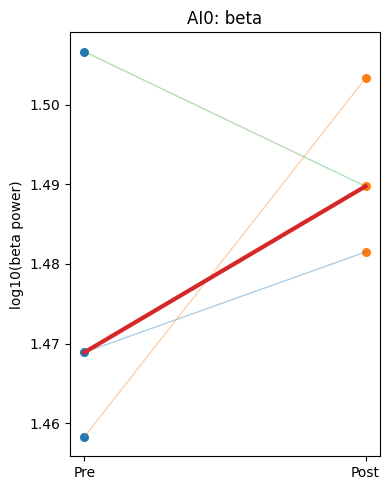

--- AI0 | beta ---
n events: 3
median pre: 29.4373
median post: 30.8856
median diff: 0.867029
median log(post/pre): 0.029028
Wilcoxon p: 0.75
Sign test p: 1.0
n_pos, n_neg, n_zero: 2, 1, 0



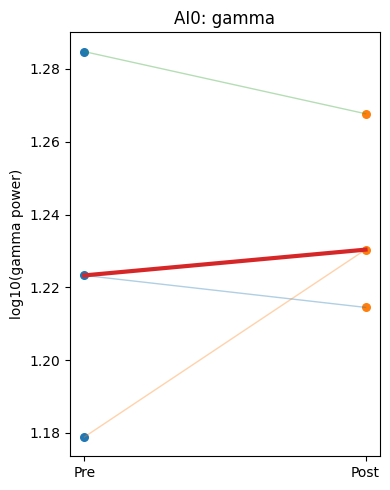

--- AI0 | gamma ---
n events: 3
median pre: 16.7216
median post: 16.9963
median diff: -0.334935
median log(post/pre): -0.0202334
Wilcoxon p: 1.0
Sign test p: 1.0
n_pos, n_neg, n_zero: 1, 2, 0

No valid events for AI2, theta
No valid events for AI2, theta


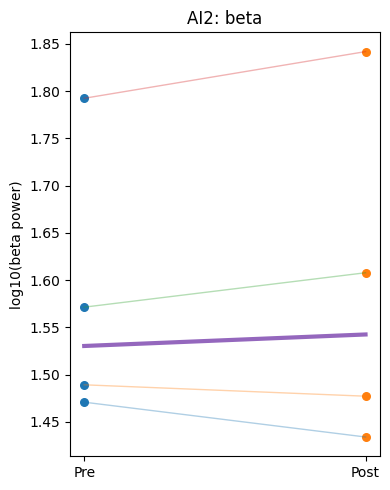

--- AI2 | beta ---
n events: 4
median pre: 34.0621
median post: 35.27
median diff: 1.2079
median log(post/pre): 0.0280484
Wilcoxon p: 0.625
Sign test p: 1.0
n_pos, n_neg, n_zero: 2, 2, 0



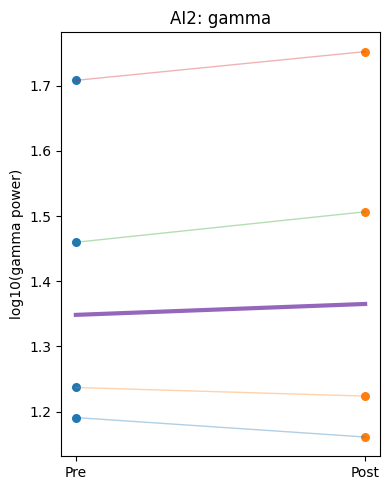

--- AI2 | gamma ---
n events: 4
median pre: 23.0439
median post: 24.423
median diff: 1.37906
median log(post/pre): 0.0355462
Wilcoxon p: 0.625
Sign test p: 1.0
n_pos, n_neg, n_zero: 2, 2, 0

=== AI0 vs AI2 | theta log-ratio ===
AI0 median: nan
AI2 median: nan
For a formal between-group test, you could add mannwhitneyu or a permutation test here.

=== AI0 vs AI2 | beta log-ratio ===
AI0 median: 0.029027990524800477
AI2 median: 0.028048387821631306
For a formal between-group test, you could add mannwhitneyu or a permutation test here.

=== AI0 vs AI2 | gamma log-ratio ===
AI0 median: -0.02023344940374621
AI2 median: 0.03554620807121462
For a formal between-group test, you could add mannwhitneyu or a permutation test here.



In [ ]:
#LFP time!!
# ============================================================
# INSTRUCTIONAL NOTEBOOK CELL:
# Compare LFP theta / beta / gamma power before vs after AI0/AI2 onsets
# using transition_df from the earlier spike-count analysis
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spikeinterface as si
import spikeinterface.preprocessing as spre

from scipy.signal import welch
from scipy.stats import wilcoxon, binomtest

# ------------------------------------------------------------------
# STEP 0. User parameters
# ------------------------------------------------------------------
# Change these as needed
#session = 'behavior_826748_2026-04-01_08-57-33'
session = session
data_type = 'raw'
probe = '2'   # '2' or 'opto'

# File from your earlier spike-count analysis
#transition_csv = '/root/capsule/scratch/826748/behavior_826748_2026-04-01_08-57-33/ephys/opto/transition_df.csv'
transition_csv = save_path

# Pre/post windows in seconds, relative to onset
# I start post at +2 s to avoid the immediate stimulation artifact.
pre_window = (-30, 0)
post_window = (2, 32)

# Welch PSD settings
welch_nperseg = 2048

# Canonical bands
bands = {
    'theta': (4, 12),
    'beta': (30, 100),
    'gamma': (100, 300),
}

# Optional channel restriction.
# Leave as None to use all LFP channels.
good_channels = None

# Small constant to avoid log/divide-by-zero issues
eps = 1e-12


# ------------------------------------------------------------------
# STEP 1. Load the transition table and inspect its structure
# ------------------------------------------------------------------
# Your attached transition_df has one row per detected transition event.
# Relevant columns:
#   channel       -> AI0 or AI2
#   transition    -> up or down
#   sample_index  -> onset sample index
#   timestamp_sec -> absolute timestamp (not needed here)
#
# For onset-locked analysis, we want ONLY the rising transitions:
#   AI0 + 'up'
#   AI2 + 'up'

transition_df = pd.read_csv(transition_csv)

print("transition_df preview:")
display(transition_df.head())

print("\ntransition_df columns:", list(transition_df.columns))
print("n rows:", len(transition_df))


# ------------------------------------------------------------------
# STEP 2. Keep only onset rows (rising edges)
# ------------------------------------------------------------------
# This matches your spike analysis idea: use the onset times as events.

onset_df = transition_df[transition_df['transition'].str.lower() == 'up'].copy()

# Split into AI0 and AI2 onset sample indices
ai0_onsets_ap_samples = np.sort(
    onset_df.loc[onset_df['channel'].str.upper() == 'AI0', 'sample_index'].to_numpy()
)
ai2_onsets_ap_samples = np.sort(
    onset_df.loc[onset_df['channel'].str.upper() == 'AI2', 'sample_index'].to_numpy()
)

print(f"\nAI0 onset count: {len(ai0_onsets_ap_samples)}")
print(f"AI2 onset count: {len(ai2_onsets_ap_samples)}")


# ------------------------------------------------------------------
# STEP 3. Load the recording and preprocess it into an LFP signal
# ------------------------------------------------------------------
# IMPORTANT CONCEPT:
# SpikeInterface recordings do not automatically give you a NumPy array.
# They give you a "recording object" that knows how to read the underlying data.
#
# Later, when we want actual signal samples, we will call:
#     recording_lfp.get_traces(start_frame=..., end_frame=...)
#
# That is the actual "extract raw signal" step.
#
# We first load the correct segment, then preprocess:
#   - bandpass 1-300 Hz to isolate LFP-ish frequencies
#   - common median reference to reduce shared noise

session_dir = session_dirs(session)

if probe == '2':
    recording_zarr = session_dir['raw_rec']
    recording = si.read_zarr(recording_zarr)
    recording = recording.select_segments(session_dir['seg_id'] - 1)

    recording_lfp = spre.bandpass_filter(recording, freq_min=1, freq_max=300)
    recording_lfp = spre.common_reference(recording_lfp, reference='global', operator='median')

elif probe == 'opto':
    recording_lfp_zarr = session_dir['raw_rec'].replace('AP', 'LFP')
    recording_lfp = si.read_zarr(recording_lfp_zarr)
    recording_lfp = recording_lfp.select_segments(session_dir['seg_id'] - 1)
    recording_lfp = spre.common_reference(recording_lfp, reference='global', operator='median')

else:
    raise ValueError("probe must be '2' or 'opto'")

fs_lfp = recording_lfp.get_sampling_frequency()
n_frames_lfp = recording_lfp.get_num_frames()
n_channels_total = recording_lfp.get_num_channels()

if good_channels is None:
    good_channels = np.arange(n_channels_total)
else:
    good_channels = np.asarray(good_channels)

print(f"\nLFP sampling rate: {fs_lfp} Hz")
print(f"Total LFP frames: {n_frames_lfp}")
print(f"Total channels: {n_channels_total}")
print(f"Using channels: {len(good_channels)}")


# ------------------------------------------------------------------
# STEP 4. Convert transition sample_index into seconds
# ------------------------------------------------------------------
# In your earlier code, onset sample indices were treated as being in a 30 kHz timebase.
# Then they were scaled into the recording's sample rate.
#
# Here I do that more explicitly:
#   AP sample index -> seconds -> LFP sample indices when needed
#
# This is easier to understand:
#   time_sec = sample_index / 30000
#
# Then later:
#   lfp_frame = round(time_sec * fs_lfp)

ai0_onsets_sec = ai0_onsets_ap_samples / 30000.0
ai2_onsets_sec = ai2_onsets_ap_samples / 30000.0


# ------------------------------------------------------------------
# STEP 5. Helper functions
# ------------------------------------------------------------------
def extract_raw_window(recording_obj, start_sec, end_sec, channels=None):
    """
    Extract raw signal samples from the recording object between start_sec and end_sec.

    This is the key signal-extraction step.

    Inputs
    ------
    recording_obj : SpikeInterface recording
        The recording object (already preprocessed to LFP here)
    start_sec, end_sec : float
        Desired window bounds in seconds
    channels : array-like or None
        Which channels to keep

    Returns
    -------
    data : array, shape (n_samples, n_channels)
        Raw LFP voltage values for that time window
    """
    fs = recording_obj.get_sampling_frequency()

    # Convert seconds into sample/frame indices in THIS recording
    start_frame = int(np.round(start_sec * fs))
    end_frame = int(np.round(end_sec * fs))

    # Clamp to valid bounds so we do not request data outside the recording
    start_frame = max(start_frame, 0)
    end_frame = min(end_frame, recording_obj.get_num_frames())

    if end_frame <= start_frame:
        return None

    # This is where the actual raw signal is read from disk/memory.
    data = recording_obj.get_traces(
        start_frame=start_frame,
        end_frame=end_frame,
        return_scaled=True
    )

    if channels is not None:
        data = data[:, channels]

    return data


def compute_psd_from_signal(data, fs, nperseg=2048):
    """
    Compute Welch PSD from raw signal.

    Input data shape is (samples, channels), because get_traces returns time first.
    Welch is easier if we transpose to (channels, samples).
    """
    if data is None or data.shape[0] < 16:
        return None, None

    data_ch_by_time = data.T
    nperseg_use = min(nperseg, data_ch_by_time.shape[1])

    freqs, psd = welch(
        data_ch_by_time,
        fs=fs,
        nperseg=nperseg_use,
        axis=1
    )
    return freqs, psd


def integrate_band_power(freqs, psd, band):
    """
    Integrate PSD inside a frequency band.

    freqs : shape (n_freq,)
    psd   : shape (n_channels, n_freq)

    Returns power per channel.
    """
    f_low, f_high = band
    mask = (freqs >= f_low) & (freqs < f_high)

    if mask.sum() == 0:
        return np.full(psd.shape[0], np.nan)

    # Area under the PSD curve within the frequency band
    bp = np.trapz(psd[:, mask], freqs[mask], axis=1)
    return bp


def compute_bandpowers_for_one_window(recording_obj, start_sec, end_sec, channels=None, nperseg=2048):
    """
    Full pipeline for one time window:
      1) extract raw signal
      2) compute PSD
      3) integrate theta/beta/gamma power

    Returns a dictionary with:
      raw signal
      frequency axis
      PSD
      per-channel band power
      mean-across-channel band power
    """
    raw = extract_raw_window(recording_obj, start_sec, end_sec, channels=channels)
    if raw is None:
        return None

    freqs, psd = compute_psd_from_signal(raw, recording_obj.get_sampling_frequency(), nperseg=nperseg)
    if freqs is None:
        return None

    band_power_ch = {}
    band_power_mean = {}

    for band_name, band_range in bands.items():
        bp_ch = integrate_band_power(freqs, psd, band_range)
        band_power_ch[band_name] = bp_ch
        band_power_mean[band_name] = np.nanmean(bp_ch)

    return {
        'raw': raw,
        'freqs': freqs,
        'psd': psd,
        'band_power_ch': band_power_ch,
        'band_power_mean': band_power_mean,
    }


def process_event_list(onsets_sec, stim_label, recording_obj, channels=None, nperseg=2048):
    """
    For each onset:
      - define pre and post windows
      - extract raw LFP from each window
      - compute PSD
      - compute theta/beta/gamma power
      - store one row per event

    Returns an event-level dataframe.
    """
    rows = []

    total_duration_sec = recording_obj.get_num_frames() / recording_obj.get_sampling_frequency()

    for event_idx, onset_sec in enumerate(onsets_sec):
        pre_start = onset_sec + pre_window[0]
        pre_end   = onset_sec + pre_window[1]
        post_start = onset_sec + post_window[0]
        post_end   = onset_sec + post_window[1]

        # Skip events too close to start/end of recording
        if pre_start < 0 or post_end > total_duration_sec:
            continue

        pre_out = compute_bandpowers_for_one_window(
            recording_obj, pre_start, pre_end, channels=channels, nperseg=nperseg
        )
        post_out = compute_bandpowers_for_one_window(
            recording_obj, post_start, post_end, channels=channels, nperseg=nperseg
        )

        if pre_out is None or post_out is None:
            continue

        row = {
            'stim_type': stim_label,
            'event_idx': event_idx,
            'onset_sec': onset_sec,
            'pre_start': pre_start,
            'pre_end': pre_end,
            'post_start': post_start,
            'post_end': post_end,
        }

        for band_name in bands.keys():
            pre_val = pre_out['band_power_mean'][band_name]
            post_val = post_out['band_power_mean'][band_name]

            row[f'{band_name}_pre'] = pre_val
            row[f'{band_name}_post'] = post_val
            row[f'{band_name}_diff'] = post_val - pre_val
            row[f'{band_name}_log_ratio'] = np.log((post_val + eps) / (pre_val + eps))

        rows.append(row)

    return pd.DataFrame(rows)


def sign_test_from_diffs(diffs):
    """
    Simple sign test on paired differences, ignoring zeros.
    """
    diffs = np.asarray(diffs)
    diffs = diffs[np.isfinite(diffs)]

    n_pos = np.sum(diffs > 0)
    n_neg = np.sum(diffs < 0)
    n_zero = np.sum(diffs == 0)
    n_eff = n_pos + n_neg

    if n_eff == 0:
        return np.nan, n_pos, n_neg, n_zero

    p = binomtest(min(n_pos, n_neg), n=n_eff, p=0.5, alternative='two-sided').pvalue
    return p, n_pos, n_neg, n_zero


def summarize_stats(df_in, stim_label, band_name):
    """
    Print paired before/after stats for one stim class and one band.
    """
    d = df_in[df_in['stim_type'] == stim_label].copy()
    d = d[np.isfinite(d[f'{band_name}_pre']) & np.isfinite(d[f'{band_name}_post'])].copy()

    if len(d) == 0:
        print(f'No valid events for {stim_label}, {band_name}')
        return

    pre = d[f'{band_name}_pre'].values
    post = d[f'{band_name}_post'].values
    diff = post - pre
    log_ratio = np.log((post + eps) / (pre + eps))

    try:
        wilcoxon_p = wilcoxon(post, pre).pvalue
    except Exception:
        wilcoxon_p = np.nan

    sign_p, n_pos, n_neg, n_zero = sign_test_from_diffs(diff)

    print(f'--- {stim_label} | {band_name} ---')
    print(f'n events: {len(d)}')
    print(f'median pre: {np.median(pre):.6g}')
    print(f'median post: {np.median(post):.6g}')
    print(f'median diff: {np.median(diff):.6g}')
    print(f'median log(post/pre): {np.median(log_ratio):.6g}')
    print(f'Wilcoxon p: {wilcoxon_p}')
    print(f'Sign test p: {sign_p}')
    print(f'n_pos, n_neg, n_zero: {n_pos}, {n_neg}, {n_zero}')
    print()


def paired_band_plot(df_in, stim_label, band_name):
    """
    Connected-dot paired plot for one band and one stim type.
    Uses log10(power) for display.
    """
    d = df_in[df_in['stim_type'] == stim_label].copy()
    d = d[np.isfinite(d[f'{band_name}_pre']) & np.isfinite(d[f'{band_name}_post'])].copy()

    if len(d) == 0:
        print(f'No valid events for {stim_label}, {band_name}')
        return

    y_pre = np.log10(d[f'{band_name}_pre'].values + eps)
    y_post = np.log10(d[f'{band_name}_post'].values + eps)

    plt.figure(figsize=(4, 5))

    for i in range(len(d)):
        plt.plot([0, 1], [y_pre[i], y_post[i]], alpha=0.35, linewidth=1)

    plt.scatter(np.zeros(len(d)), y_pre, s=30)
    plt.scatter(np.ones(len(d)), y_post, s=30)

    # Median overlay
    plt.plot([0, 1], [np.median(y_pre), np.median(y_post)], linewidth=3)

    plt.xticks([0, 1], ['Pre', 'Post'])
    plt.ylabel(f'log10({band_name} power)')
    plt.title(f'{stim_label}: {band_name}')
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# STEP 6. Run the event-level analysis
# ------------------------------------------------------------------
# Each row in bandpower_df will represent one stimulation onset event.
# For each event, we compute mean theta/beta/gamma power across channels
# in the pre window and in the post window.

bandpower_ai0 = process_event_list(
    ai0_onsets_sec,
    stim_label='AI0',
    recording_obj=recording_lfp,
    channels=good_channels,
    nperseg=welch_nperseg
)

bandpower_ai2 = process_event_list(
    ai2_onsets_sec,
    stim_label='AI2',
    recording_obj=recording_lfp,
    channels=good_channels,
    nperseg=welch_nperseg
)

bandpower_df = pd.concat([bandpower_ai0, bandpower_ai2], ignore_index=True)

print("\nEvent-level bandpower dataframe:")
display(bandpower_df.head())
print("Total valid events:", len(bandpower_df))


# ------------------------------------------------------------------
# STEP 7. Example: inspect one event's extracted raw signal
# ------------------------------------------------------------------
# This is here for learning.
# It shows exactly what "raw signal extraction" looks like for one event.
# We take the first valid AI0 onset, extract the pre window, and plot a few channels.

if len(ai0_onsets_sec) > 0:
    onset_sec_demo = ai0_onsets_sec[0]
    raw_demo = extract_raw_window(
        recording_lfp,
        onset_sec_demo + pre_window[0],
        onset_sec_demo + pre_window[1],
        channels=good_channels[:min(5, len(good_channels))]
    )

    if raw_demo is not None:
        t_demo = np.arange(raw_demo.shape[0]) / fs_lfp + pre_window[0]

        plt.figure(figsize=(10, 6))
        offset = 0
        for ch in range(raw_demo.shape[1]):
            plt.plot(t_demo, raw_demo[:, ch] + offset, linewidth=1, label=f'ch {good_channels[ch]}')
            offset += 200  # vertical offset just so traces do not overlap visually

        plt.axvline(0, linestyle='--')
        plt.xlabel('Time relative to onset (s)')
        plt.ylabel('LFP signal + offset')
        plt.title('Example extracted raw LFP pre-window (first few channels)')
        plt.legend(loc='upper right', fontsize=8)
        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------------
# STEP 8. Paired plots and statistics
# ------------------------------------------------------------------
for stim_label in ['AI0', 'AI2']:
    for band_name in bands.keys():
        paired_band_plot(bandpower_df, stim_label, band_name)
        summarize_stats(bandpower_df, stim_label, band_name)


# ------------------------------------------------------------------
# STEP 9. Optional direct AI0 vs AI2 comparison on change scores
# ------------------------------------------------------------------
# Here we compare log-ratio = log(post/pre) across AI0 vs AI2.
# This tells you whether the spectral effect differs between the two stimulation types.

for band_name in bands.keys():
    d0 = bandpower_df.loc[bandpower_df['stim_type'] == 'AI0', f'{band_name}_log_ratio'].dropna().values
    d2 = bandpower_df.loc[bandpower_df['stim_type'] == 'AI2', f'{band_name}_log_ratio'].dropna().values

    print(f'=== AI0 vs AI2 | {band_name} log-ratio ===')
    print(f'AI0 median: {np.median(d0) if len(d0) else np.nan}')
    print(f'AI2 median: {np.median(d2) if len(d2) else np.nan}')
    print("For a formal between-group test, you could add mannwhitneyu or a permutation test here.")
    print()


# ------------------------------------------------------------------
# STEP 10. Save the event-level results if you want
# ------------------------------------------------------------------
# Uncomment if desired:
# save_path = os.path.join(session_dir[f'opto_dir_{data_type}'], 'lfp_bandpower_before_after_transition_onsets.csv')
# bandpower_df.to_csv(save_path, index=False)
# print(f"Saved: {save_path}")

AI0 onset count: 3
AI2 onset count: 3
LFP sampling rate: 30000.0 Hz
Total LFP frames: 92325460
Using channels: 384
AI0: kept 3 events after boundary checks
AI2: kept 3 events after boundary checks


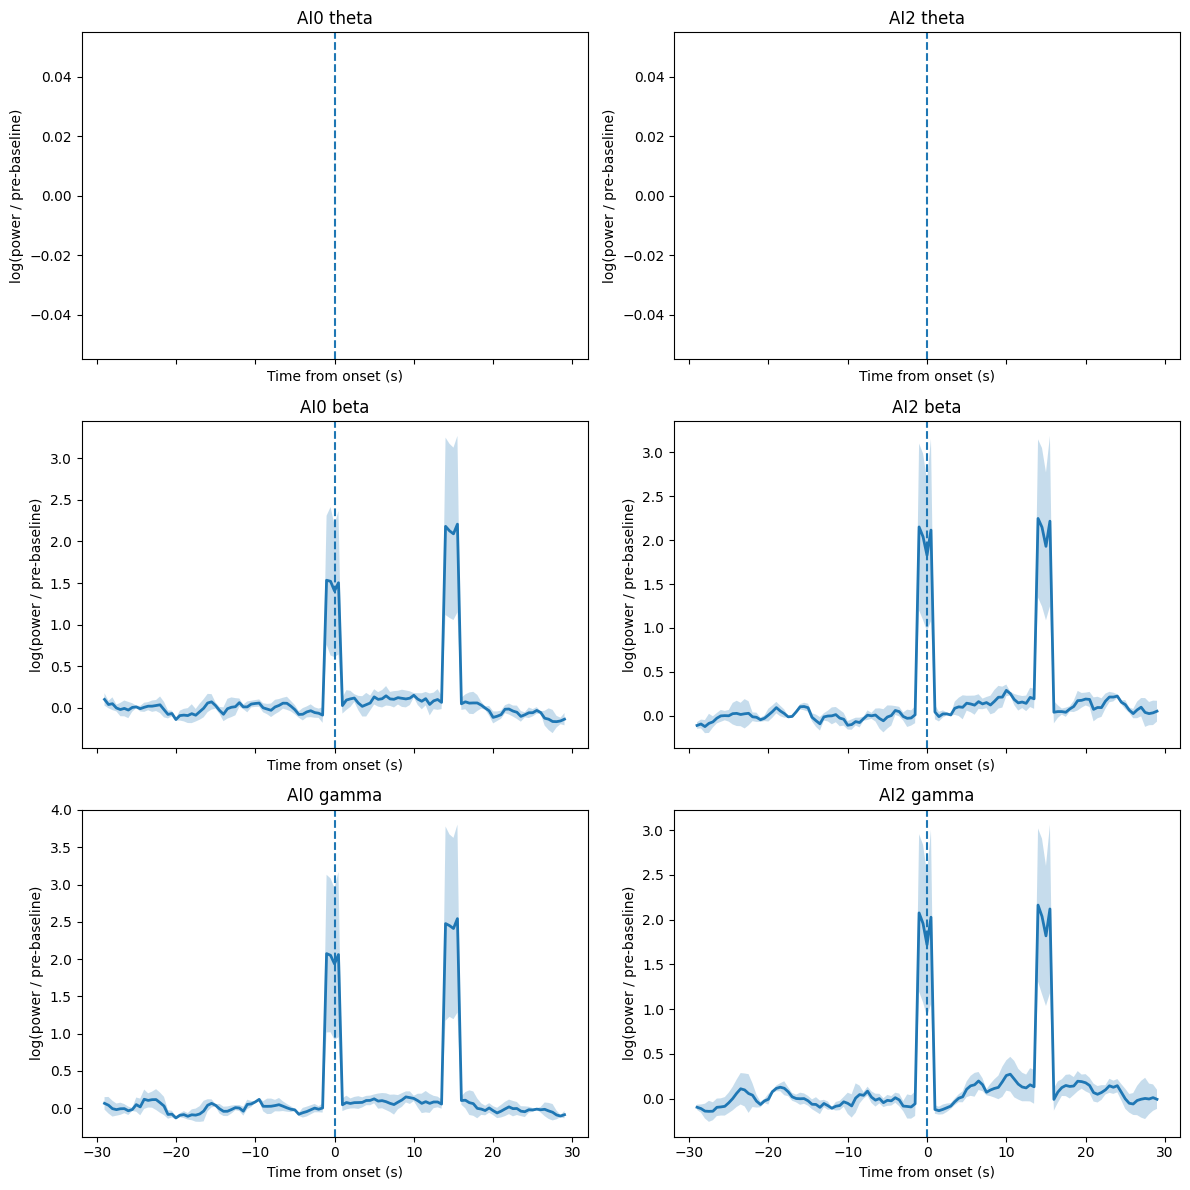

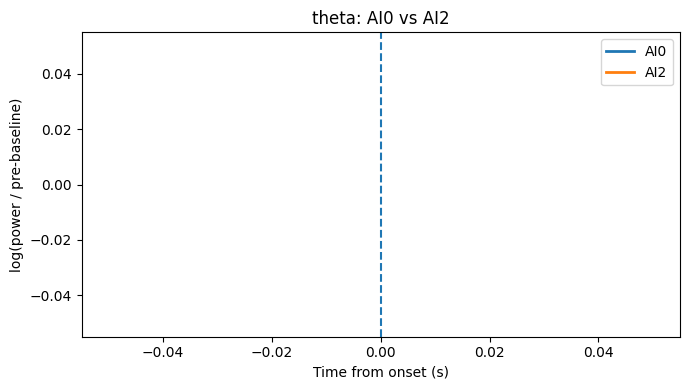

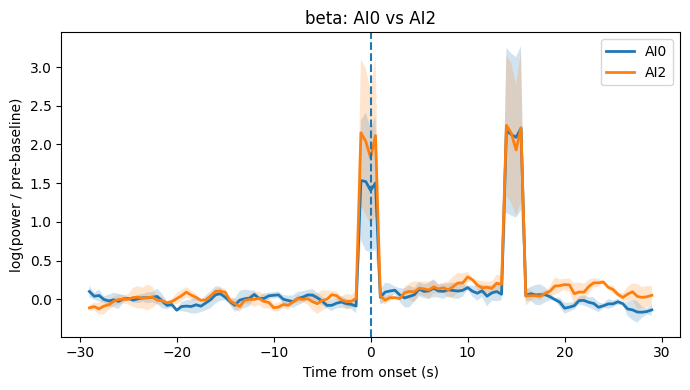

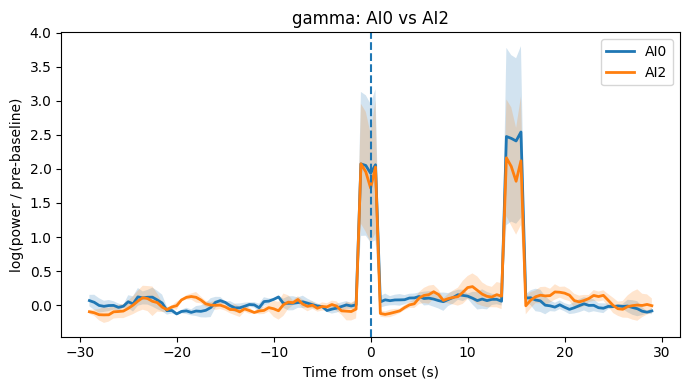

bandpower_trace_df preview:


,stim_type,band,event_idx,t_rel,value
0,AI0,theta,0,-29.0,NaN
1,AI0,theta,0,-28.5,NaN
2,AI0,theta,0,-28.0,NaN
3,AI0,theta,0,-27.5,NaN
4,AI0,theta,0,-27.0,NaN


n rows: 2106


In [41]:
# ============================================================
# SELF-CONTAINED CELL:
# Plot time-resolved theta / beta / gamma power around AI0 / AI2 onsets
# Independent of the "#LFP time!!" cell
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spikeinterface as si
import spikeinterface.preprocessing as spre

from scipy.signal import welch
from scipy.stats import sem

# ------------------------------------------------------------------
# STEP 0. User parameters
# ------------------------------------------------------------------
session = session
data_type = 'raw'
probe = '2'   # '2' or 'opto'

# transition_df source
transition_csv = save_path   # or set explicit path to transition_df.csv

# Time-resolved analysis parameters
trace_window = (-30, 30)      # seconds relative to onset
slide_win_sec = 2.0
slide_step_sec = 0.5

baseline_subtract = False
baseline_log_ratio = True
baseline_window = (-20, -5)

# PSD settings
welch_nperseg = 2048

# Canonical bands
bands = {
    'theta': (4, 12),
    'beta': (30, 100),
    'gamma': (100, 300),
}

# Optional channel restriction
good_channels = None

eps = 1e-12

# ------------------------------------------------------------------
# STEP 1. Load transitions and extract AI0 / AI2 onset times
# ------------------------------------------------------------------
transition_df = pd.read_csv(transition_csv)

onset_df = transition_df[transition_df['transition'].str.lower() == 'up'].copy()

ai0_onsets_ap_samples = np.sort(
    onset_df.loc[onset_df['channel'].str.upper() == 'AI0', 'sample_index'].to_numpy()
)
ai2_onsets_ap_samples = np.sort(
    onset_df.loc[onset_df['channel'].str.upper() == 'AI2', 'sample_index'].to_numpy()
)

# Original code treated transition sample_index as AP sample index at 30 kHz
ai0_onsets_sec = ai0_onsets_ap_samples / 30000.0
ai2_onsets_sec = ai2_onsets_ap_samples / 30000.0

print(f"AI0 onset count: {len(ai0_onsets_sec)}")
print(f"AI2 onset count: {len(ai2_onsets_sec)}")

# ------------------------------------------------------------------
# STEP 2. Load LFP recording
# ------------------------------------------------------------------
session_dir = session_dirs(session)

if probe == '2':
    recording_zarr = session_dir['raw_rec']
    recording = si.read_zarr(recording_zarr)
    recording = recording.select_segments(session_dir['seg_id'] - 1)

    recording_lfp = spre.bandpass_filter(recording, freq_min=1, freq_max=300)
    recording_lfp = spre.common_reference(recording_lfp, reference='global', operator='median')

elif probe == 'opto':
    recording_lfp_zarr = session_dir['raw_rec'].replace('AP', 'LFP')
    recording_lfp = si.read_zarr(recording_lfp_zarr)
    recording_lfp = recording_lfp.select_segments(session_dir['seg_id'] - 1)
    recording_lfp = spre.common_reference(recording_lfp, reference='global', operator='median')

else:
    raise ValueError("probe must be '2' or 'opto'")

fs_lfp = recording_lfp.get_sampling_frequency()
n_frames_lfp = recording_lfp.get_num_frames()
n_channels_total = recording_lfp.get_num_channels()

if good_channels is None:
    good_channels = np.arange(n_channels_total)
else:
    good_channels = np.asarray(good_channels)

print(f"LFP sampling rate: {fs_lfp} Hz")
print(f"Total LFP frames: {n_frames_lfp}")
print(f"Using channels: {len(good_channels)}")

# ------------------------------------------------------------------
# STEP 3. Helper functions
# ------------------------------------------------------------------
def extract_raw_window(recording_obj, start_sec, end_sec, channels=None):
    fs = recording_obj.get_sampling_frequency()
    start_frame = int(np.round(start_sec * fs))
    end_frame = int(np.round(end_sec * fs))

    start_frame = max(start_frame, 0)
    end_frame = min(end_frame, recording_obj.get_num_frames())

    if end_frame <= start_frame:
        return None

    data = recording_obj.get_traces(
        start_frame=start_frame,
        end_frame=end_frame,
        return_scaled=True
    )

    if channels is not None:
        data = data[:, channels]

    return data


def bandpower_from_raw_chunk(raw_chunk, fs, bands, nperseg=2048):
    if raw_chunk is None or raw_chunk.shape[0] < 16:
        return None, None

    data_ch_by_time = raw_chunk.T
    nperseg_use = min(nperseg, data_ch_by_time.shape[1])

    freqs, psd = welch(
        data_ch_by_time,
        fs=fs,
        nperseg=nperseg_use,
        axis=1
    )

    band_ch = {}
    band_mean = {}

    for band_name, (f_low, f_high) in bands.items():
        mask = (freqs >= f_low) & (freqs < f_high)
        if mask.sum() == 0:
            bp_ch = np.full(psd.shape[0], np.nan)
        else:
            bp_ch = np.trapz(psd[:, mask], freqs[mask], axis=1)

        band_ch[band_name] = bp_ch
        band_mean[band_name] = np.nanmean(bp_ch)

    return band_mean, band_ch


def sliding_bandpower_trace_for_event(
    recording_obj,
    onset_sec,
    trace_window,
    slide_win_sec,
    slide_step_sec,
    bands,
    channels=None,
    welch_nperseg=2048,
):
    fs = recording_obj.get_sampling_frequency()

    full_start_sec = onset_sec + trace_window[0]
    full_end_sec = onset_sec + trace_window[1]

    total_duration_sec = recording_obj.get_num_frames() / fs
    if full_start_sec < 0 or full_end_sec > total_duration_sec:
        return None, None

    full_raw = extract_raw_window(
        recording_obj,
        full_start_sec,
        full_end_sec,
        channels=channels
    )
    if full_raw is None:
        return None, None

    full_t = np.arange(full_raw.shape[0]) / fs + trace_window[0]

    half_win = slide_win_sec / 2
    t_centers = np.arange(
        trace_window[0] + half_win,
        trace_window[1] - half_win + 1e-9,
        slide_step_sec
    )

    band_trace = {band_name: [] for band_name in bands.keys()}

    for tc in t_centers:
        mask = (full_t >= tc - half_win) & (full_t < tc + half_win)
        raw_chunk = full_raw[mask, :]

        band_mean, _ = bandpower_from_raw_chunk(
            raw_chunk,
            fs=fs,
            bands=bands,
            nperseg=welch_nperseg
        )

        if band_mean is None:
            for band_name in bands.keys():
                band_trace[band_name].append(np.nan)
        else:
            for band_name in bands.keys():
                band_trace[band_name].append(band_mean[band_name])

    for band_name in band_trace:
        band_trace[band_name] = np.asarray(band_trace[band_name])

    return t_centers, band_trace


def build_event_trace_matrix(
    recording_obj,
    onsets_sec,
    stim_label,
    trace_window,
    slide_win_sec,
    slide_step_sec,
    bands,
    channels=None,
    welch_nperseg=2048,
):
    kept_onsets = []
    trace_rows = {band_name: [] for band_name in bands.keys()}
    t_centers_ref = None

    for onset_sec in onsets_sec:
        t_centers, band_trace = sliding_bandpower_trace_for_event(
            recording_obj=recording_obj,
            onset_sec=onset_sec,
            trace_window=trace_window,
            slide_win_sec=slide_win_sec,
            slide_step_sec=slide_step_sec,
            bands=bands,
            channels=channels,
            welch_nperseg=welch_nperseg,
        )

        if t_centers is None:
            continue

        if t_centers_ref is None:
            t_centers_ref = t_centers

        kept_onsets.append(onset_sec)
        for band_name in bands.keys():
            trace_rows[band_name].append(band_trace[band_name])

    if t_centers_ref is None:
        return None, None, None

    trace_dict = {}
    for band_name in bands.keys():
        trace_dict[band_name] = np.asarray(trace_rows[band_name])

    kept_onsets = np.asarray(kept_onsets)
    print(f"{stim_label}: kept {len(kept_onsets)} events after boundary checks")
    return t_centers_ref, trace_dict, kept_onsets


def normalize_trace_matrix(trace_mat, t_centers, baseline_window, subtract=False, log_ratio=True, eps=1e-12):
    if trace_mat is None:
        return None

    base_mask = (t_centers >= baseline_window[0]) & (t_centers < baseline_window[1])
    if base_mask.sum() == 0:
        return trace_mat.copy()

    out = np.full_like(trace_mat, np.nan, dtype=float)

    for i in range(trace_mat.shape[0]):
        baseline_mean = np.nanmean(trace_mat[i, base_mask])

        if subtract:
            out[i, :] = trace_mat[i, :] - baseline_mean
        elif log_ratio:
            out[i, :] = np.log((trace_mat[i, :] + eps) / (baseline_mean + eps))
        else:
            out[i, :] = trace_mat[i, :]

    return out


def plot_mean_sem_trace(t, mat, title, ylabel):
    if mat is None or mat.size == 0:
        print(f"No data for {title}")
        return

    mean_trace = np.nanmean(mat, axis=0)
    sem_trace = sem(mat, axis=0, nan_policy='omit')

    plt.plot(t, mean_trace, linewidth=2)
    plt.fill_between(t, mean_trace - sem_trace, mean_trace + sem_trace, alpha=0.25)
    plt.axvline(0, linestyle='--')
    plt.xlabel('Time from onset (s)')
    plt.ylabel(ylabel)
    plt.title(title)


def overlay_two_groups(t1, mat1, label1, t2, mat2, label2, title, ylabel):
    plt.figure(figsize=(7, 4))

    if mat1 is not None and mat1.size > 0:
        m1 = np.nanmean(mat1, axis=0)
        s1 = sem(mat1, axis=0, nan_policy='omit')
        plt.plot(t1, m1, linewidth=2, label=label1)
        plt.fill_between(t1, m1 - s1, m1 + s1, alpha=0.2)

    if mat2 is not None and mat2.size > 0:
        m2 = np.nanmean(mat2, axis=0)
        s2 = sem(mat2, axis=0, nan_policy='omit')
        plt.plot(t2, m2, linewidth=2, label=label2)
        plt.fill_between(t2, m2 - s2, m2 + s2, alpha=0.2)

    plt.axvline(0, linestyle='--')
    plt.xlabel('Time from onset (s)')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# STEP 4. Build AI0 and AI2 matrices
# ------------------------------------------------------------------
t_ai0, traces_ai0, kept_ai0 = build_event_trace_matrix(
    recording_obj=recording_lfp,
    onsets_sec=ai0_onsets_sec,
    stim_label='AI0',
    trace_window=trace_window,
    slide_win_sec=slide_win_sec,
    slide_step_sec=slide_step_sec,
    bands=bands,
    channels=good_channels,
    welch_nperseg=welch_nperseg,
)

t_ai2, traces_ai2, kept_ai2 = build_event_trace_matrix(
    recording_obj=recording_lfp,
    onsets_sec=ai2_onsets_sec,
    stim_label='AI2',
    trace_window=trace_window,
    slide_win_sec=slide_win_sec,
    slide_step_sec=slide_step_sec,
    bands=bands,
    channels=good_channels,
    welch_nperseg=welch_nperseg,
)

# ------------------------------------------------------------------
# STEP 5. Normalize
# ------------------------------------------------------------------
if traces_ai0 is not None:
    traces_ai0_norm = {
        band_name: normalize_trace_matrix(
            traces_ai0[band_name],
            t_ai0,
            baseline_window=baseline_window,
            subtract=baseline_subtract,
            log_ratio=baseline_log_ratio,
            eps=eps
        )
        for band_name in bands.keys()
    }
else:
    traces_ai0_norm = None

if traces_ai2 is not None:
    traces_ai2_norm = {
        band_name: normalize_trace_matrix(
            traces_ai2[band_name],
            t_ai2,
            baseline_window=baseline_window,
            subtract=baseline_subtract,
            log_ratio=baseline_log_ratio,
            eps=eps
        )
        for band_name in bands.keys()
    }
else:
    traces_ai2_norm = None

# ------------------------------------------------------------------
# STEP 6. Plot mean ± SEM
# ------------------------------------------------------------------
if baseline_log_ratio:
    ylab = 'log(power / pre-baseline)'
elif baseline_subtract:
    ylab = 'power - pre-baseline'
else:
    ylab = 'band power'

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12), sharex=True)

for r, band_name in enumerate(bands.keys()):
    plt.sca(axes[r, 0])
    plot_mean_sem_trace(
        t_ai0,
        None if traces_ai0_norm is None else traces_ai0_norm[band_name],
        title=f'AI0 {band_name}',
        ylabel=ylab
    )

    plt.sca(axes[r, 1])
    plot_mean_sem_trace(
        t_ai2,
        None if traces_ai2_norm is None else traces_ai2_norm[band_name],
        title=f'AI2 {band_name}',
        ylabel=ylab
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# STEP 7. Overlay AI0 vs AI2
# ------------------------------------------------------------------
for band_name in bands.keys():
    overlay_two_groups(
        t_ai0,
        None if traces_ai0_norm is None else traces_ai0_norm[band_name],
        'AI0',
        t_ai2,
        None if traces_ai2_norm is None else traces_ai2_norm[band_name],
        'AI2',
        title=f'{band_name}: AI0 vs AI2',
        ylabel=ylab
    )

# ------------------------------------------------------------------
# STEP 8. Optional tidy dataframe
# ------------------------------------------------------------------
rows = []

if traces_ai0_norm is not None:
    for band_name in bands.keys():
        mat = traces_ai0_norm[band_name]
        for event_i in range(mat.shape[0]):
            for ti, tval in enumerate(t_ai0):
                rows.append({
                    'stim_type': 'AI0',
                    'band': band_name,
                    'event_idx': event_i,
                    't_rel': tval,
                    'value': mat[event_i, ti]
                })

if traces_ai2_norm is not None:
    for band_name in bands.keys():
        mat = traces_ai2_norm[band_name]
        for event_i in range(mat.shape[0]):
            for ti, tval in enumerate(t_ai2):
                rows.append({
                    'stim_type': 'AI2',
                    'band': band_name,
                    'event_idx': event_i,
                    't_rel': tval,
                    'value': mat[event_i, ti]
                })

bandpower_trace_df = pd.DataFrame(rows)

print("bandpower_trace_df preview:")
display(bandpower_trace_df.head())
print("n rows:", len(bandpower_trace_df))

AI0: kept 3 events after boundary checks
AI2: kept 4 events after boundary checks


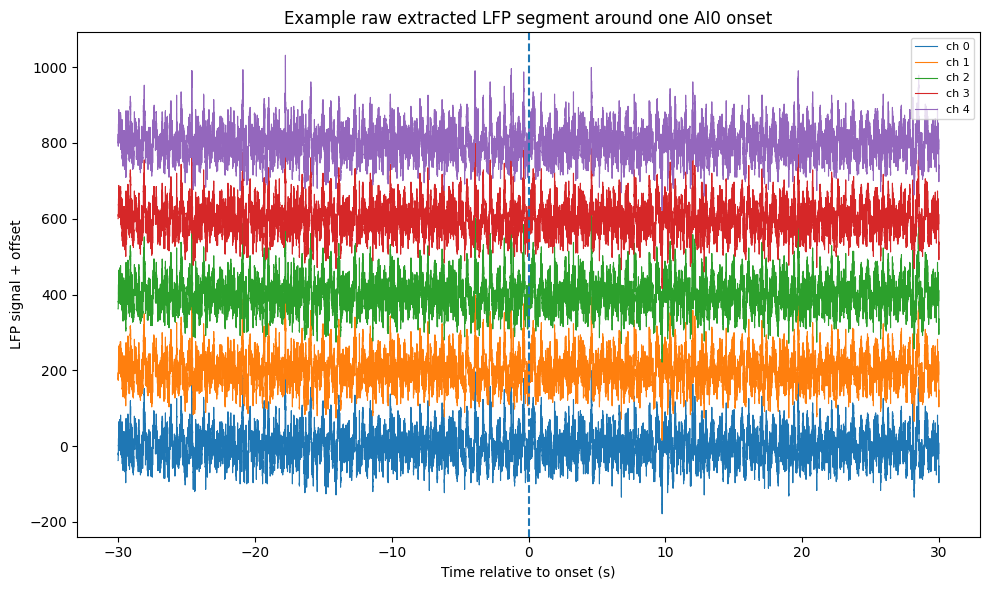

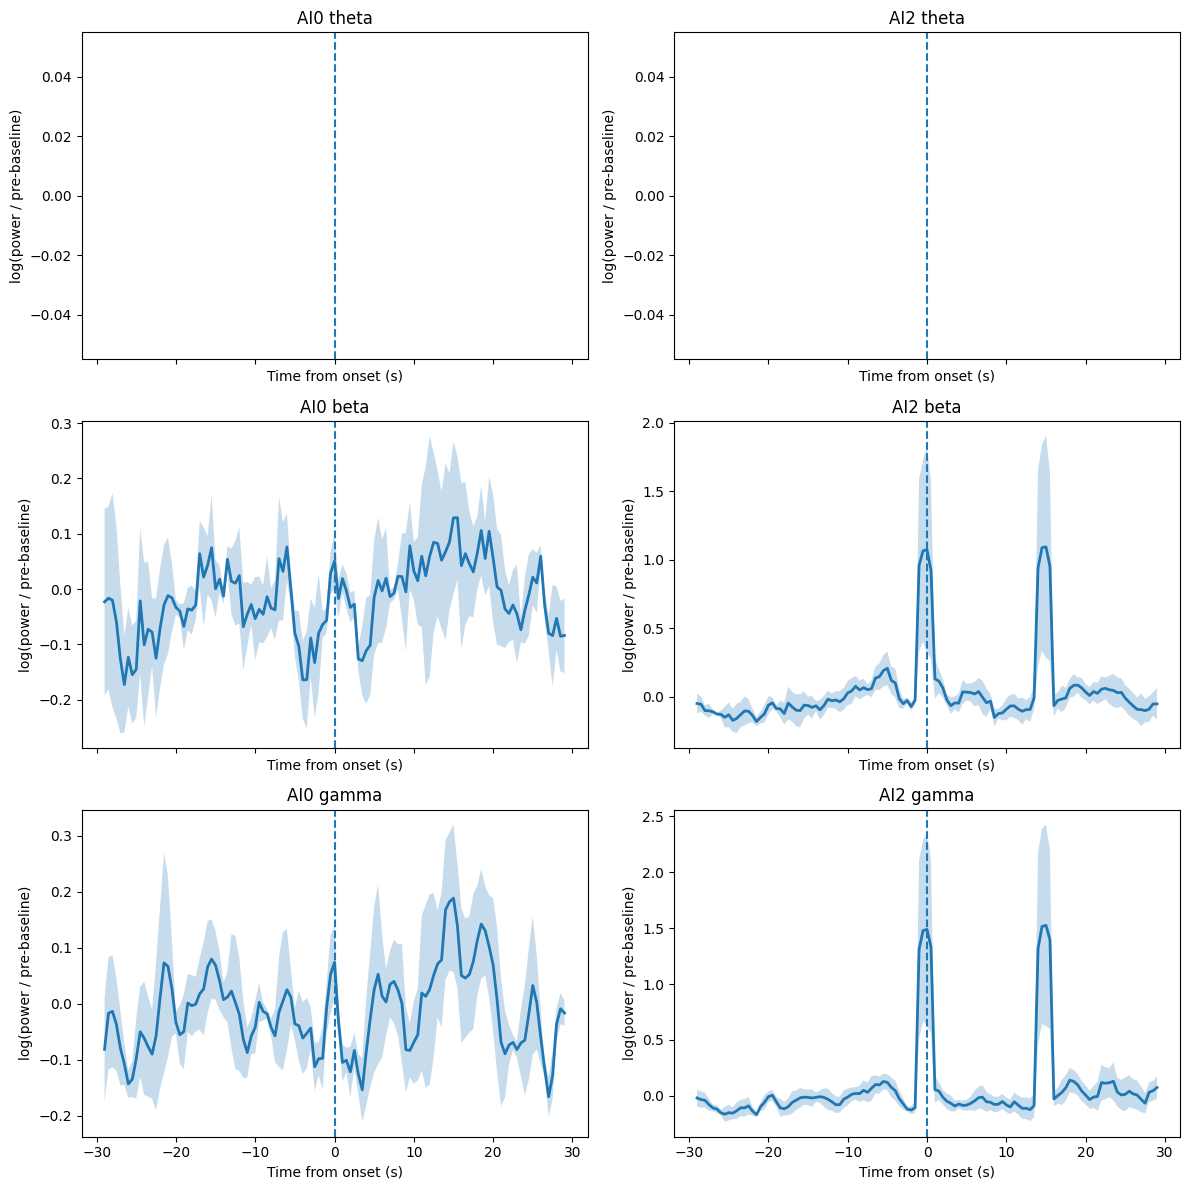

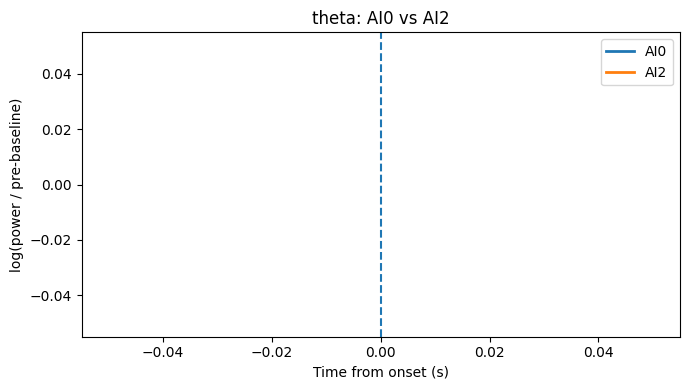

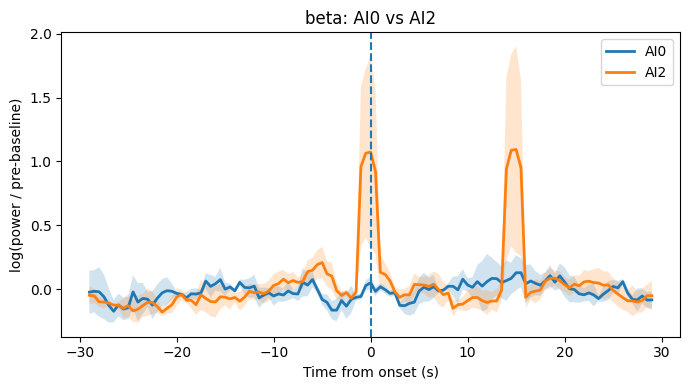

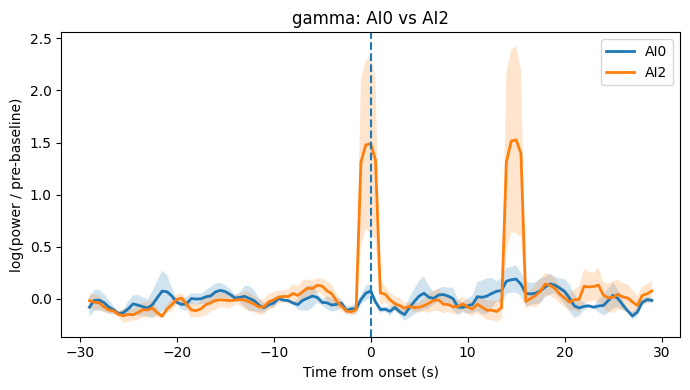

bandpower_trace_df preview:


,stim_type,band,event_idx,t_rel,value
0,AI0,theta,0,-29.0,NaN
1,AI0,theta,0,-28.5,NaN
2,AI0,theta,0,-28.0,NaN
3,AI0,theta,0,-27.5,NaN
4,AI0,theta,0,-27.0,NaN


In [18]:
# ============================================================
# INSTRUCTIONAL NOTEBOOK CELL:
# Plot time-resolved theta / beta / gamma power around AI0 / AI2 onsets
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import sem

# ------------------------------------------------------------------
# STEP 0. User parameters
# ------------------------------------------------------------------
# Overall display window around each onset
trace_window = (-30, 30)   # seconds relative to onset

# Sliding analysis window used to estimate PSD at each timepoint
# Example: 2 s window sliding every 0.5 s
slide_win_sec = 2.0
slide_step_sec = 0.5

# If True, subtract each event's own pre-onset mean band power
baseline_subtract = False

# If True, convert to log-ratio relative to each event's own pre-onset mean:
#   log(power / baseline_mean)
baseline_log_ratio = True

# Pre-onset baseline range used for normalization
baseline_window = (-20, -5)

# Optional: limit channels
# Set to None to use all channels already defined in good_channels
channels_for_trace = good_channels

# ------------------------------------------------------------------
# STEP 1. Helper function:
# compute band power in one short raw signal chunk
# ------------------------------------------------------------------
def bandpower_from_raw_chunk(raw_chunk, fs, bands, nperseg=2048):
    """
    raw_chunk shape: (samples, channels)

    Returns
    -------
    band_mean : dict
        mean band power across channels
    band_ch : dict
        per-channel band power
    """
    if raw_chunk is None or raw_chunk.shape[0] < 16:
        return None, None

    data_ch_by_time = raw_chunk.T
    nperseg_use = min(nperseg, data_ch_by_time.shape[1])

    freqs, psd = welch(
        data_ch_by_time,
        fs=fs,
        nperseg=nperseg_use,
        axis=1
    )

    band_ch = {}
    band_mean = {}

    for band_name, (f_low, f_high) in bands.items():
        mask = (freqs >= f_low) & (freqs < f_high)
        if mask.sum() == 0:
            bp_ch = np.full(psd.shape[0], np.nan)
        else:
            bp_ch = np.trapz(psd[:, mask], freqs[mask], axis=1)

        band_ch[band_name] = bp_ch
        band_mean[band_name] = np.nanmean(bp_ch)

    return band_mean, band_ch


# ------------------------------------------------------------------
# STEP 2. Helper function:
# for ONE event, make a time-resolved band-power trace
# ------------------------------------------------------------------
def sliding_bandpower_trace_for_event(
    recording_obj,
    onset_sec,
    trace_window,
    slide_win_sec,
    slide_step_sec,
    bands,
    channels=None,
    welch_nperseg=2048,
):
    """
    For one onset:
      1) extract one large raw LFP segment around onset
      2) move a short sliding window across that segment
      3) compute band power in each sliding window

    Why do this?
    Instead of one pre and one post value, this gives a full time-course
    of theta/beta/gamma power around the stimulation onset.

    Returns
    -------
    t_centers : array, shape (n_timebins,)
        center time of each sliding window, relative to onset
    band_trace : dict
        band_trace[band_name] -> array of shape (n_timebins,)
    """
    fs = recording_obj.get_sampling_frequency()

    # Define the full raw segment we want to extract around onset
    full_start_sec = onset_sec + trace_window[0]
    full_end_sec = onset_sec + trace_window[1]

    # If event is too close to beginning or end, skip it
    total_duration_sec = recording_obj.get_num_frames() / fs
    if full_start_sec < 0 or full_end_sec > total_duration_sec:
        return None, None

    # ---- This is the actual raw signal extraction step ----
    full_raw = extract_raw_window(
        recording_obj,
        full_start_sec,
        full_end_sec,
        channels=channels
    )
    if full_raw is None:
        return None, None

    # Time axis for the extracted raw segment, relative to onset
    # Example: if trace_window = (-30, 30), this spans -30 to +30 s
    full_t = np.arange(full_raw.shape[0]) / fs + trace_window[0]

    # Define centers of sliding windows
    # Each center gets a small window of length slide_win_sec around it
    half_win = slide_win_sec / 2
    t_centers = np.arange(
        trace_window[0] + half_win,
        trace_window[1] - half_win + 1e-9,
        slide_step_sec
    )

    band_trace = {band_name: [] for band_name in bands.keys()}

    for tc in t_centers:
        # Identify samples belonging to this local sliding window
        mask = (full_t >= tc - half_win) & (full_t < tc + half_win)

        raw_chunk = full_raw[mask, :]
        band_mean, band_ch = bandpower_from_raw_chunk(
            raw_chunk,
            fs=fs,
            bands=bands,
            nperseg=welch_nperseg
        )

        if band_mean is None:
            for band_name in bands.keys():
                band_trace[band_name].append(np.nan)
        else:
            for band_name in bands.keys():
                band_trace[band_name].append(band_mean[band_name])

    for band_name in band_trace:
        band_trace[band_name] = np.asarray(band_trace[band_name])

    return t_centers, band_trace


# ------------------------------------------------------------------
# STEP 3. Helper function:
# stack traces across events of one stimulus type
# ------------------------------------------------------------------
def build_event_trace_matrix(
    recording_obj,
    onsets_sec,
    stim_label,
    trace_window,
    slide_win_sec,
    slide_step_sec,
    bands,
    channels=None,
    welch_nperseg=2048,
):
    """
    Build a matrix of time-resolved band-power traces across all events.

    Returns
    -------
    t_centers : array
    trace_dict : dict
        trace_dict[band_name] = 2D array, shape (n_events, n_timebins)
    kept_onsets : array
        onset times that survived edge checks
    """
    kept_onsets = []
    trace_rows = {band_name: [] for band_name in bands.keys()}
    t_centers_ref = None

    for onset_sec in onsets_sec:
        t_centers, band_trace = sliding_bandpower_trace_for_event(
            recording_obj=recording_obj,
            onset_sec=onset_sec,
            trace_window=trace_window,
            slide_win_sec=slide_win_sec,
            slide_step_sec=slide_step_sec,
            bands=bands,
            channels=channels,
            welch_nperseg=welch_nperseg,
        )

        if t_centers is None:
            continue

        if t_centers_ref is None:
            t_centers_ref = t_centers

        kept_onsets.append(onset_sec)
        for band_name in bands.keys():
            trace_rows[band_name].append(band_trace[band_name])

    if t_centers_ref is None:
        return None, None, None

    trace_dict = {}
    for band_name in bands.keys():
        trace_dict[band_name] = np.asarray(trace_rows[band_name])

    kept_onsets = np.asarray(kept_onsets)

    print(f"{stim_label}: kept {len(kept_onsets)} events after boundary checks")
    return t_centers_ref, trace_dict, kept_onsets


# ------------------------------------------------------------------
# STEP 4. Build AI0 and AI2 time-resolved trace matrices
# ------------------------------------------------------------------
t_ai0, traces_ai0, kept_ai0 = build_event_trace_matrix(
    recording_obj=recording_lfp,
    onsets_sec=ai0_onsets_sec,
    stim_label='AI0',
    trace_window=trace_window,
    slide_win_sec=slide_win_sec,
    slide_step_sec=slide_step_sec,
    bands=bands,
    channels=channels_for_trace,
    welch_nperseg=welch_nperseg,
)

t_ai2, traces_ai2, kept_ai2 = build_event_trace_matrix(
    recording_obj=recording_lfp,
    onsets_sec=ai2_onsets_sec,
    stim_label='AI2',
    trace_window=trace_window,
    slide_win_sec=slide_win_sec,
    slide_step_sec=slide_step_sec,
    bands=bands,
    channels=channels_for_trace,
    welch_nperseg=welch_nperseg,
)


# ------------------------------------------------------------------
# STEP 5. Optional baseline normalization
# ------------------------------------------------------------------
def normalize_trace_matrix(trace_mat, t_centers, baseline_window, subtract=False, log_ratio=True, eps=1e-12):
    """
    Normalize each event trace to its own baseline.

    trace_mat shape: (n_events, n_timebins)

    Options:
    - subtract=True      -> power - baseline_mean
    - log_ratio=True     -> log(power / baseline_mean)

    If both are False, returns raw traces unchanged.
    """
    if trace_mat is None:
        return None

    base_mask = (t_centers >= baseline_window[0]) & (t_centers < baseline_window[1])
    if base_mask.sum() == 0:
        return trace_mat.copy()

    out = np.full_like(trace_mat, np.nan, dtype=float)

    for i in range(trace_mat.shape[0]):
        baseline_mean = np.nanmean(trace_mat[i, base_mask])

        if subtract:
            out[i, :] = trace_mat[i, :] - baseline_mean
        elif log_ratio:
            out[i, :] = np.log((trace_mat[i, :] + eps) / (baseline_mean + eps))
        else:
            out[i, :] = trace_mat[i, :]

    return out


if traces_ai0 is not None:
    traces_ai0_norm = {}
    for band_name in bands.keys():
        traces_ai0_norm[band_name] = normalize_trace_matrix(
            traces_ai0[band_name],
            t_ai0,
            baseline_window=baseline_window,
            subtract=baseline_subtract,
            log_ratio=baseline_log_ratio,
            eps=eps
        )
else:
    traces_ai0_norm = None

if traces_ai2 is not None:
    traces_ai2_norm = {}
    for band_name in bands.keys():
        traces_ai2_norm[band_name] = normalize_trace_matrix(
            traces_ai2[band_name],
            t_ai2,
            baseline_window=baseline_window,
            subtract=baseline_subtract,
            log_ratio=baseline_log_ratio,
            eps=eps
        )
else:
    traces_ai2_norm = None


# ------------------------------------------------------------------
# STEP 6. Show one example raw extracted segment for learning
# ------------------------------------------------------------------
# This is just to visualize what the raw LFP data look like before PSD.
if len(ai0_onsets_sec) > 0:
    demo_onset = ai0_onsets_sec[0]
    demo_raw = extract_raw_window(
        recording_lfp,
        demo_onset + trace_window[0],
        demo_onset + trace_window[1],
        channels=channels_for_trace[:min(5, len(channels_for_trace))]
    )

    if demo_raw is not None:
        demo_t = np.arange(demo_raw.shape[0]) / fs_lfp + trace_window[0]

        plt.figure(figsize=(10, 6))
        offset = 0
        for ch in range(demo_raw.shape[1]):
            plt.plot(demo_t, demo_raw[:, ch] + offset, linewidth=0.8, label=f'ch {channels_for_trace[ch]}')
            offset += 200

        plt.axvline(0, linestyle='--')
        plt.xlabel('Time relative to onset (s)')
        plt.ylabel('LFP signal + offset')
        plt.title('Example raw extracted LFP segment around one AI0 onset')
        plt.legend(fontsize=8, loc='upper right')
        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------------
# STEP 7. Plot mean ± SEM traces across events
# ------------------------------------------------------------------
def plot_mean_sem_trace(t, mat, title, ylabel):
    """
    mat shape: (n_events, n_timebins)
    """
    if mat is None or mat.size == 0:
        print(f"No data for {title}")
        return

    mean_trace = np.nanmean(mat, axis=0)
    sem_trace = sem(mat, axis=0, nan_policy='omit')

    plt.plot(t, mean_trace, linewidth=2)
    plt.fill_between(t, mean_trace - sem_trace, mean_trace + sem_trace, alpha=0.25)
    plt.axvline(0, linestyle='--')
    plt.xlabel('Time from onset (s)')
    plt.ylabel(ylabel)
    plt.title(title)


if baseline_log_ratio:
    ylab = 'log(power / pre-baseline)'
elif baseline_subtract:
    ylab = 'power - pre-baseline'
else:
    ylab = 'band power'

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12), sharex=True)

for r, band_name in enumerate(bands.keys()):
    # AI0
    plt.sca(axes[r, 0])
    plot_mean_sem_trace(
        t_ai0,
        None if traces_ai0_norm is None else traces_ai0_norm[band_name],
        title=f'AI0 {band_name}',
        ylabel=ylab
    )

    # AI2
    plt.sca(axes[r, 1])
    plot_mean_sem_trace(
        t_ai2,
        None if traces_ai2_norm is None else traces_ai2_norm[band_name],
        title=f'AI2 {band_name}',
        ylabel=ylab
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# STEP 8. Optional: overlay AI0 and AI2 on the same axes
# ------------------------------------------------------------------
def overlay_two_groups(t1, mat1, label1, t2, mat2, label2, title, ylabel):
    plt.figure(figsize=(7, 4))

    if mat1 is not None and mat1.size > 0:
        m1 = np.nanmean(mat1, axis=0)
        s1 = sem(mat1, axis=0, nan_policy='omit')
        plt.plot(t1, m1, linewidth=2, label=label1)
        plt.fill_between(t1, m1 - s1, m1 + s1, alpha=0.2)

    if mat2 is not None and mat2.size > 0:
        m2 = np.nanmean(mat2, axis=0)
        s2 = sem(mat2, axis=0, nan_policy='omit')
        plt.plot(t2, m2, linewidth=2, label=label2)
        plt.fill_between(t2, m2 - s2, m2 + s2, alpha=0.2)

    plt.axvline(0, linestyle='--')
    plt.xlabel('Time from onset (s)')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

for band_name in bands.keys():
    overlay_two_groups(
        t_ai0,
        None if traces_ai0_norm is None else traces_ai0_norm[band_name],
        'AI0',
        t_ai2,
        None if traces_ai2_norm is None else traces_ai2_norm[band_name],
        'AI2',
        title=f'{band_name}: AI0 vs AI2',
        ylabel=ylab
    )


# ------------------------------------------------------------------
# STEP 9. Optional: store traces in a tidy dataframe
# ------------------------------------------------------------------
# This is useful if later you want to run stats at each time bin
# or save the time-resolved results.

rows = []

if traces_ai0_norm is not None:
    for band_name in bands.keys():
        mat = traces_ai0_norm[band_name]
        for event_i in range(mat.shape[0]):
            for ti, tval in enumerate(t_ai0):
                rows.append({
                    'stim_type': 'AI0',
                    'band': band_name,
                    'event_idx': event_i,
                    't_rel': tval,
                    'value': mat[event_i, ti]
                })

if traces_ai2_norm is not None:
    for band_name in bands.keys():
        mat = traces_ai2_norm[band_name]
        for event_i in range(mat.shape[0]):
            for ti, tval in enumerate(t_ai2):
                rows.append({
                    'stim_type': 'AI2',
                    'band': band_name,
                    'event_idx': event_i,
                    't_rel': tval,
                    'value': mat[event_i, ti]
                })

bandpower_trace_df = pd.DataFrame(rows)

print("bandpower_trace_df preview:")
display(bandpower_trace_df.head())

# Uncomment to save if desired:
# trace_save_path = os.path.join(session_dir[f'opto_dir_{data_type}'], 'lfp_bandpower_traces_transition_onsets.csv')
# bandpower_trace_df.to_csv(trace_save_path, index=False)
# print(f"Saved: {trace_save_path}")

No data for AI0 theta
No data for AI2 theta


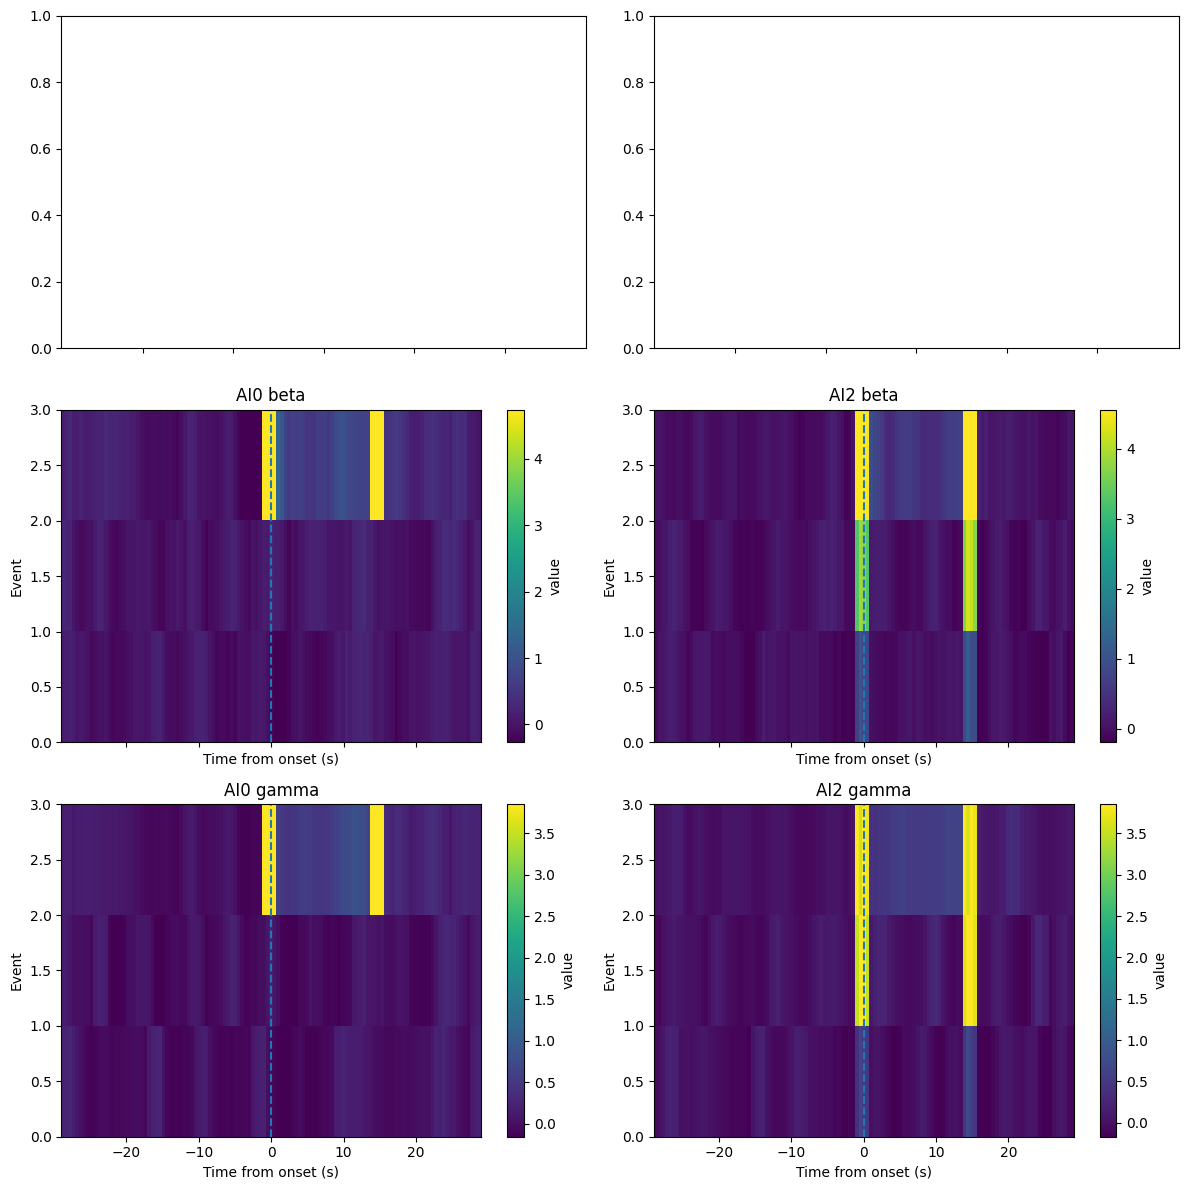

No data for theta | AI0
No data for theta | AI2


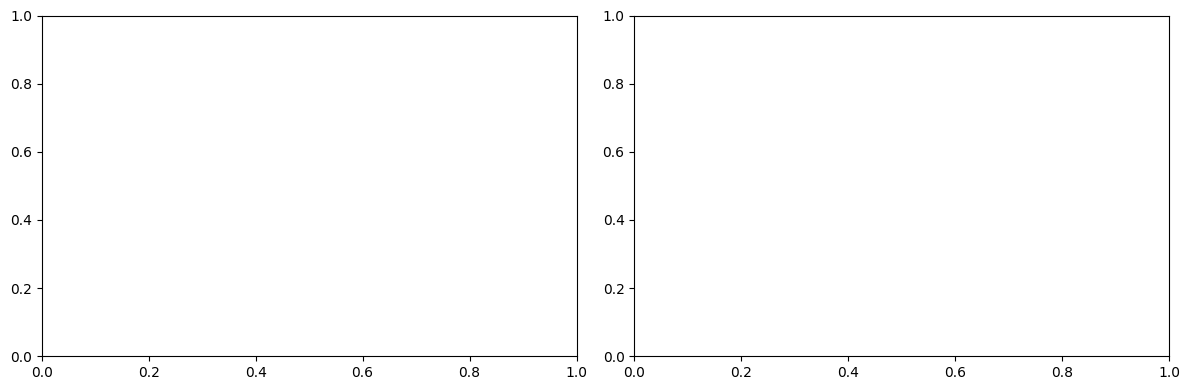

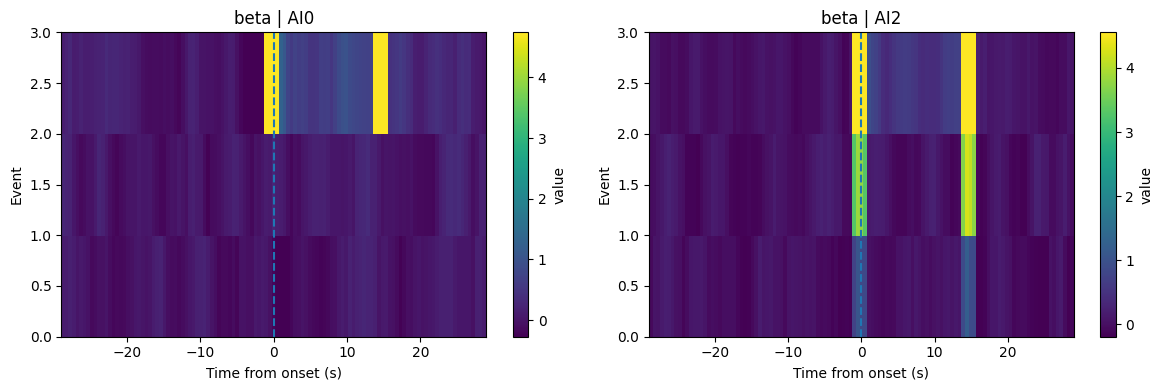

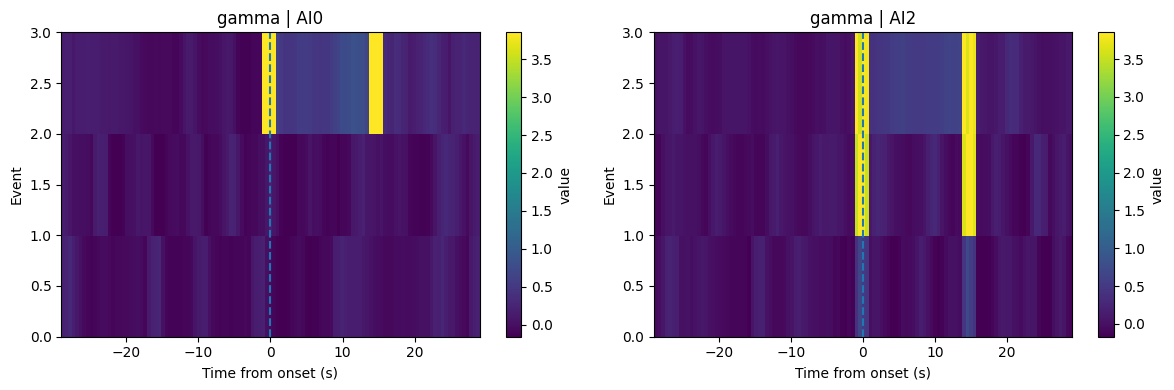

No data for AI0 theta
No data for AI2 theta


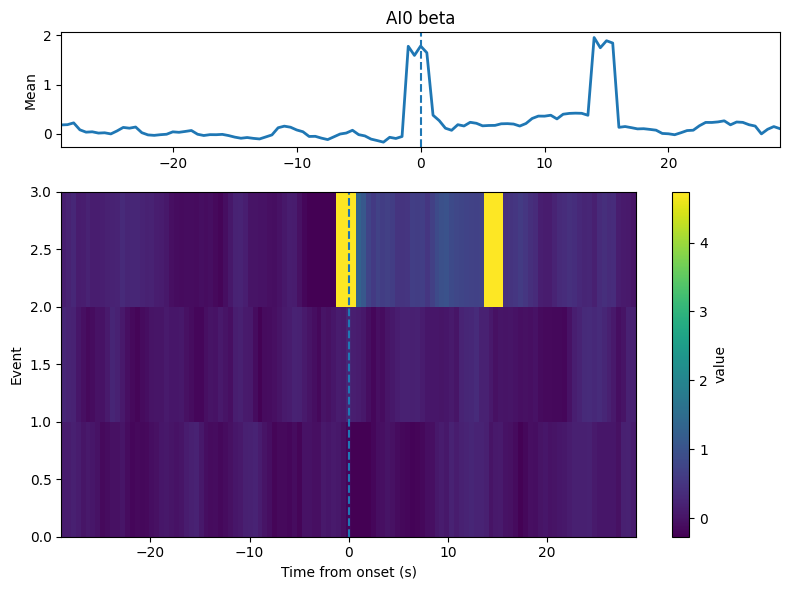

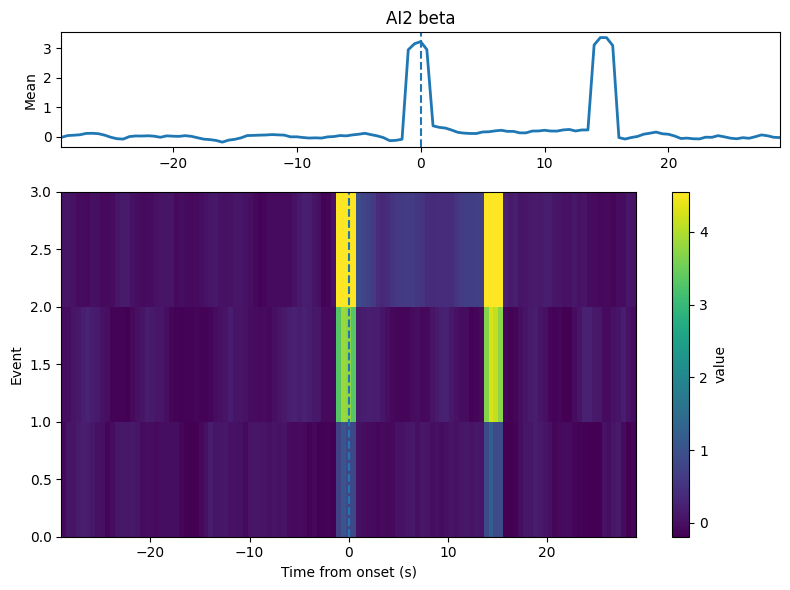

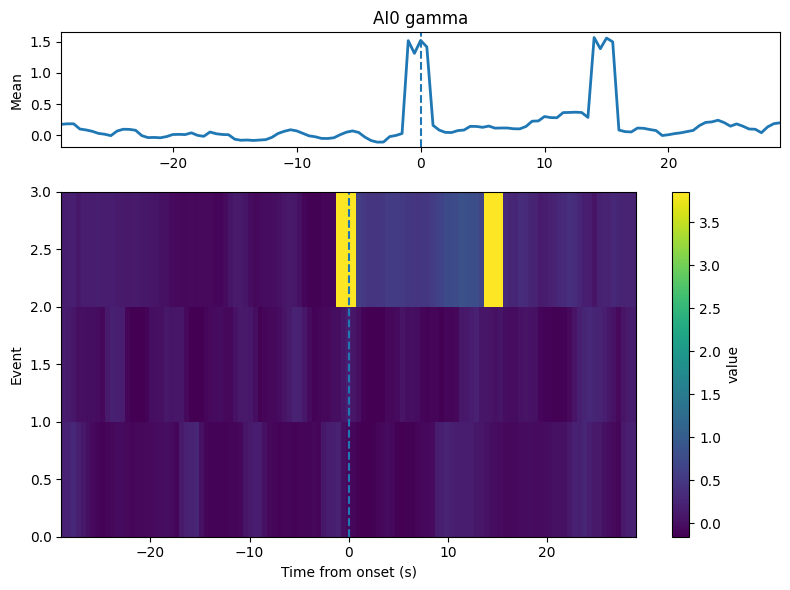

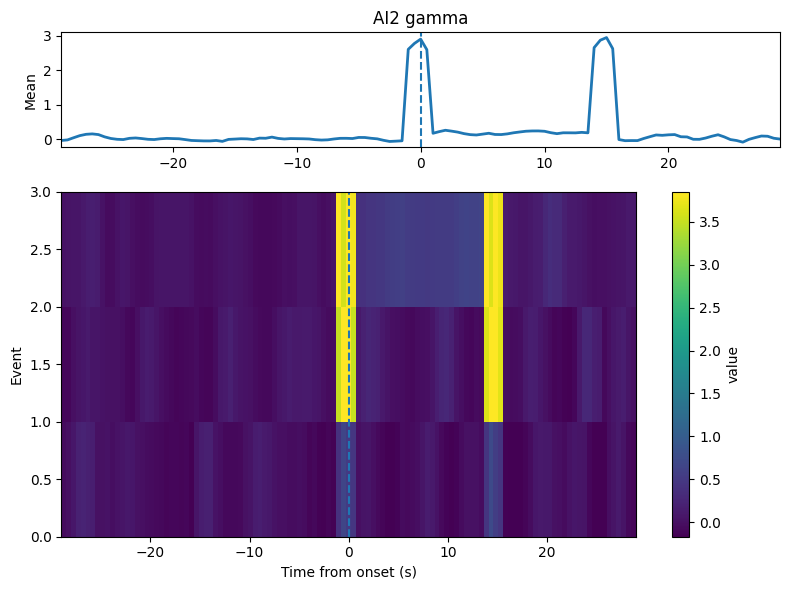

In [8]:
# ============================================================
# INSTRUCTIONAL NOTEBOOK CELL:
# Heat maps of time-resolved theta / beta / gamma power around onset
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# STEP 0. User parameters
# ------------------------------------------------------------------
# How to display each event row
# 'raw'         -> plot values as stored in bandpower_trace_df
# 'zscore_row'  -> z-score each event across time before plotting
heatmap_mode = 'raw'   # 'raw' or 'zscore_row'

# How to sort events
# 'none'       -> keep original event order
# 'post_mean'  -> sort by mean response in a post-onset window
sort_mode = 'post_mean'   # 'none' or 'post_mean'

# Window used if sort_mode == 'post_mean'
sort_window = (0, 10)

# Percentile-based color clipping to reduce outlier domination
clip_percentiles = (2, 98)

# ------------------------------------------------------------------
# STEP 1. Helper functions
# ------------------------------------------------------------------
def make_event_time_matrix(df_long, stim_type, band_name):
    """
    Convert the long-form dataframe into a 2D matrix:
        rows = events
        cols = time bins

    Input long dataframe columns:
      stim_type, band, event_idx, t_rel, value

    Returns
    -------
    mat : array, shape (n_events, n_timebins)
    t_vals : array, shape (n_timebins,)
    event_ids : array, shape (n_events,)
    """
    d = df_long[
        (df_long['stim_type'] == stim_type) &
        (df_long['band'] == band_name)
    ].copy()

    if len(d) == 0:
        return None, None, None

    # Pivot long -> wide
    pivot = d.pivot_table(
        index='event_idx',
        columns='t_rel',
        values='value'
    )

    # Ensure deterministic ordering
    pivot = pivot.sort_index(axis=0).sort_index(axis=1)

    event_ids = pivot.index.to_numpy()
    t_vals = pivot.columns.to_numpy(dtype=float)
    mat = pivot.to_numpy()

    return mat, t_vals, event_ids


def zscore_rows(mat):
    """
    Z-score each event (row) across time.
    Useful when you care more about temporal pattern than absolute scale.
    """
    if mat is None:
        return None

    out = np.full_like(mat, np.nan, dtype=float)
    for i in range(mat.shape[0]):
        row = mat[i, :]
        mu = np.nanmean(row)
        sd = np.nanstd(row)
        if np.isfinite(sd) and sd > 0:
            out[i, :] = (row - mu) / sd
        else:
            out[i, :] = row - mu
    return out


def sort_event_matrix(mat, t_vals, mode='none', sort_window=(0, 10)):
    """
    Optionally sort events by some summary of their response.

    mode='post_mean':
      sort by each event's mean value in sort_window
    """
    if mat is None:
        return None, None

    if mode == 'none':
        order = np.arange(mat.shape[0])

    elif mode == 'post_mean':
        mask = (t_vals >= sort_window[0]) & (t_vals < sort_window[1])
        if mask.sum() == 0:
            order = np.arange(mat.shape[0])
        else:
            score = np.nanmean(mat[:, mask], axis=1)
            order = np.argsort(score)   # low -> high
    else:
        raise ValueError("mode must be 'none' or 'post_mean'")

    return mat[order, :], order


def robust_clim(mat, percentiles=(2, 98), symmetric=False):
    """
    Compute display color limits using percentiles.
    """
    vals = mat[np.isfinite(mat)]
    if len(vals) == 0:
        return None, None

    if symmetric:
        vmax = np.nanpercentile(np.abs(vals), percentiles[1])
        vmin = -vmax
    else:
        vmin = np.nanpercentile(vals, percentiles[0])
        vmax = np.nanpercentile(vals, percentiles[1])

    return vmin, vmax


def plot_heatmap(mat, t_vals, title, mode='raw', percentiles=(2, 98)):
    """
    Plot one heat map.
    """
    if mat is None or mat.size == 0:
        print(f"No data for {title}")
        return

    if mode == 'zscore_row':
        mat_plot = zscore_rows(mat)
        cmap = 'bwr'
        vmin, vmax = robust_clim(mat_plot, percentiles=percentiles, symmetric=True)
        cbar_label = 'row z-score'
    else:
        mat_plot = mat
        cmap = 'viridis'
        vmin, vmax = robust_clim(mat_plot, percentiles=percentiles, symmetric=False)
        cbar_label = 'value'

    plt.imshow(
        mat_plot,
        aspect='auto',
        origin='lower',
        extent=[t_vals[0], t_vals[-1], 0, mat_plot.shape[0]],
        interpolation='none',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
    plt.axvline(0, linestyle='--')
    plt.xlabel('Time from onset (s)')
    plt.ylabel('Event')
    plt.title(title)
    plt.colorbar(label=cbar_label)


# ------------------------------------------------------------------
# STEP 2. Build and plot heat maps for each band and stim type
# ------------------------------------------------------------------
stim_types = ['AI0', 'AI2']
band_names = list(bands.keys())

fig, axes = plt.subplots(
    nrows=len(band_names),
    ncols=len(stim_types),
    figsize=(12, 12),
    sharex=True,
    sharey=False
)

for r, band_name in enumerate(band_names):
    for c, stim_type in enumerate(stim_types):
        mat, t_vals, event_ids = make_event_time_matrix(
            bandpower_trace_df,
            stim_type=stim_type,
            band_name=band_name
        )

        if mat is not None:
            mat_sorted, order = sort_event_matrix(
                mat,
                t_vals,
                mode=sort_mode,
                sort_window=sort_window
            )
        else:
            mat_sorted = None

        plt.sca(axes[r, c])
        plot_heatmap(
            mat_sorted,
            t_vals,
            title=f'{stim_type} {band_name}',
            mode=heatmap_mode,
            percentiles=clip_percentiles
        )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# STEP 3. Optional: make separate larger figures, one band at a time
# ------------------------------------------------------------------
for band_name in band_names:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    for c, stim_type in enumerate(stim_types):
        mat, t_vals, event_ids = make_event_time_matrix(
            bandpower_trace_df,
            stim_type=stim_type,
            band_name=band_name
        )

        if mat is not None:
            mat_sorted, order = sort_event_matrix(
                mat,
                t_vals,
                mode=sort_mode,
                sort_window=sort_window
            )
        else:
            mat_sorted = None

        plt.sca(axes[c])
        plot_heatmap(
            mat_sorted,
            t_vals,
            title=f'{band_name} | {stim_type}',
            mode=heatmap_mode,
            percentiles=clip_percentiles
        )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# STEP 4. Optional: overlay the mean trace above each heat map
# ------------------------------------------------------------------
def plot_mean_and_heatmap(mat, t_vals, title, mode='raw', percentiles=(2, 98)):
    """
    Show a mean trace on top and event heat map below.
    """
    if mat is None or mat.size == 0:
        print(f"No data for {title}")
        return

    if mode == 'zscore_row':
        mat_plot = zscore_rows(mat)
        ylab = 'row z-score'
    else:
        mat_plot = mat
        ylab = 'value'

    mean_trace = np.nanmean(mat_plot, axis=0)

    fig = plt.figure(figsize=(8, 6))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 3])

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(t_vals, mean_trace, linewidth=2)
    ax1.axvline(0, linestyle='--')
    ax1.set_ylabel('Mean')
    ax1.set_title(title)

    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    if mode == 'zscore_row':
        cmap = 'bwr'
        vmin, vmax = robust_clim(mat_plot, percentiles=percentiles, symmetric=True)
    else:
        cmap = 'viridis'
        vmin, vmax = robust_clim(mat_plot, percentiles=percentiles, symmetric=False)

    im = ax2.imshow(
        mat_plot,
        aspect='auto',
        origin='lower',
        extent=[t_vals[0], t_vals[-1], 0, mat_plot.shape[0]],
        interpolation='none',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
    ax2.axvline(0, linestyle='--')
    ax2.set_xlabel('Time from onset (s)')
    ax2.set_ylabel('Event')
    plt.colorbar(im, ax=ax2, label=ylab)
    plt.tight_layout()
    plt.show()


# Example usage for all combinations:
for band_name in band_names:
    for stim_type in stim_types:
        mat, t_vals, event_ids = make_event_time_matrix(
            bandpower_trace_df,
            stim_type=stim_type,
            band_name=band_name
        )

        if mat is not None:
            mat_sorted, order = sort_event_matrix(
                mat,
                t_vals,
                mode=sort_mode,
                sort_window=sort_window
            )
            plot_mean_and_heatmap(
                mat_sorted,
                t_vals,
                title=f'{stim_type} {band_name}',
                mode=heatmap_mode,
                percentiles=clip_percentiles
            )

In [9]:
print("bands:", bands)
print()

print("=== Raw trace dict checks ===")
print("traces_ai0 is None:", traces_ai0 is None)
print("traces_ai2 is None:", traces_ai2 is None)

if traces_ai0 is not None:
    print("AI0 keys:", list(traces_ai0.keys()))
    for k, v in traces_ai0.items():
        print("AI0", k, type(v), None if v is None else np.shape(v), None if v is None else np.size(v))
print()

if traces_ai2 is not None:
    print("AI2 keys:", list(traces_ai2.keys()))
    for k, v in traces_ai2.items():
        print("AI2", k, type(v), None if v is None else np.shape(v), None if v is None else np.size(v))
print()

print("=== Normalized trace dict checks ===")
print("traces_ai0_norm is None:", traces_ai0_norm is None)
print("traces_ai2_norm is None:", traces_ai2_norm is None)

if traces_ai0_norm is not None:
    print("AI0 norm keys:", list(traces_ai0_norm.keys()))
    for k, v in traces_ai0_norm.items():
        print("AI0 norm", k, type(v), None if v is None else np.shape(v), None if v is None else np.size(v))
print()

if traces_ai2_norm is not None:
    print("AI2 norm keys:", list(traces_ai2_norm.keys()))
    for k, v in traces_ai2_norm.items():
        print("AI2 norm", k, type(v), None if v is None else np.shape(v), None if v is None else np.size(v))
print()

print("=== bandpower_trace_df checks ===")
print("Rows by stim and band:")
print(bandpower_trace_df.groupby(['stim_type', 'band']).size())

bands: {'theta': (4, 12), 'beta': (30, 100), 'gamma': (100, 300)}

=== Raw trace dict checks ===
traces_ai0 is None: False
traces_ai2 is None: False
AI0 keys: ['theta', 'beta', 'gamma']
AI0 theta <class 'numpy.ndarray'> (3, 117) 351
AI0 beta <class 'numpy.ndarray'> (3, 117) 351
AI0 gamma <class 'numpy.ndarray'> (3, 117) 351

AI2 keys: ['theta', 'beta', 'gamma']
AI2 theta <class 'numpy.ndarray'> (3, 117) 351
AI2 beta <class 'numpy.ndarray'> (3, 117) 351
AI2 gamma <class 'numpy.ndarray'> (3, 117) 351

=== Normalized trace dict checks ===
traces_ai0_norm is None: False
traces_ai2_norm is None: False
AI0 norm keys: ['theta', 'beta', 'gamma']
AI0 norm theta <class 'numpy.ndarray'> (3, 117) 351
AI0 norm beta <class 'numpy.ndarray'> (3, 117) 351
AI0 norm gamma <class 'numpy.ndarray'> (3, 117) 351

AI2 norm keys: ['theta', 'beta', 'gamma']
AI2 norm theta <class 'numpy.ndarray'> (3, 117) 351
AI2 norm beta <class 'numpy.ndarray'> (3, 117) 351
AI2 norm gamma <class 'numpy.ndarray'> (3, 117) 351



In [10]:
for stim_label in ['AI0', 'AI2']:
    for source_name, source in [('raw', traces_ai0 if stim_label == 'AI0' else traces_ai2),
                                ('norm', traces_ai0_norm if stim_label == 'AI0' else traces_ai2_norm)]:
        arr = source['theta']
        print(f'--- {stim_label} {source_name} theta ---')
        print('shape:', arr.shape)
        print('n finite:', np.isfinite(arr).sum())
        print('n nan:', np.isnan(arr).sum())
        print('min:', np.nanmin(arr))
        print('max:', np.nanmax(arr))
        print('mean:', np.nanmean(arr))
        print()

--- AI0 raw theta ---
shape: (3, 117)
n finite: 0
n nan: 351
min: nan
max: nan
mean: nan

--- AI0 norm theta ---
shape: (3, 117)
n finite: 0
n nan: 351
min: nan
max: nan
mean: nan

--- AI2 raw theta ---
shape: (3, 117)
n finite: 0
n nan: 351
min: nan
max: nan
mean: nan

--- AI2 norm theta ---
shape: (3, 117)
n finite: 0
n nan: 351
min: nan
max: nan
mean: nan

